In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.cm as cm
# import seaborn as sns
import re

In [26]:
def plot_all(df, memb_name="POPC-CHOL",outdir="./plots"):
    # --- Extract and sort LGFE columns numerically ---
    lgfe_cols = [col for col in df.columns if col.startswith("lgfe_")]
    lgfe_cols_sorted = sorted(lgfe_cols, key=lambda x: int(re.findall(r'\d+', x)[0]))
    lgfe_data = df[lgfe_cols_sorted]

    # --- Identify outlier profiles ---
    threshold_max = 0.9*1e2  # Adjust as needed
    threshold_min = -0.9*1e2  # Adjust as needed
    outlier_max_mask = (lgfe_data > threshold_max).any(axis=1)
    outlier_min_mask = (lgfe_data < threshold_min).any(axis=1)
    outliers_max = df[outlier_max_mask]
    outliers_min = df[outlier_min_mask]

    nan_locations = df.isna()
    nan_positions = nan_locations.stack()[nan_locations.stack()].index

    if not nan_positions.empty:
        print("NaN found at:")
        print(nan_positions)

    # --- Report outliers ---
    if not outliers_max.empty:
        print("Outlier molecule(s) detected (value > 90 kcal/mol):")
        print(outliers_max[["Name"]])
    elif not outliers_min.empty:
        print("Outlier molecule(s) detected (value < -90 kcal/mol):")
        print(outliers_min[["Name"]])
    else:
        print("No outliers detected.")

    # --- Filter out outliers ---
    df_clean = df[~outlier_max_mask | ~outlier_min_mask]
    lgfe_data_clean = df_clean[lgfe_cols_sorted]

    # --- Plot remaining LGFE profiles ---
    plt.figure(figsize=(8, 6))
    for i, row in lgfe_data_clean.iterrows():
        plt.plot(row.values, alpha=0.4, linewidth=1)

    plt.xlabel("Z-slice (LGFE index)", fontsize=16)
    plt.ylabel("LGFE (kcal/mol)", fontsize=16)
    plt.ylim([-6,25])
    plt.title(f"{memb_name.replace('_', ' ')}", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.grid(True)
    plt.tight_layout()
    plt.tight_layout()
    output_file = f"{outdir}/LGFE_profiles_{memb_name.lower().replace('-', '_')}.png"
    # output_file = f"LGFE_profiles_{memb_name.lower().replace('-', '_')}.png"
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    return lgfe_data_clean, lgfe_cols_sorted, df_clean


In [13]:
# --- Load data ---
df_popc = pd.read_csv("../data/popc_chol-biogen-P_app_lgfe.csv")
df_popc_halogen = pd.read_csv("../data/popc_chol_halogen-biogen-P_app_lgfe.csv")
df_pampa = pd.read_csv("../data/pampa-biogen-P_app_lgfe.csv")
df_bbb = pd.read_csv("../data/bbb-biogen-P_app_lgfe.csv")

No outliers detected.
No outliers detected.
No outliers detected.
No outliers detected.


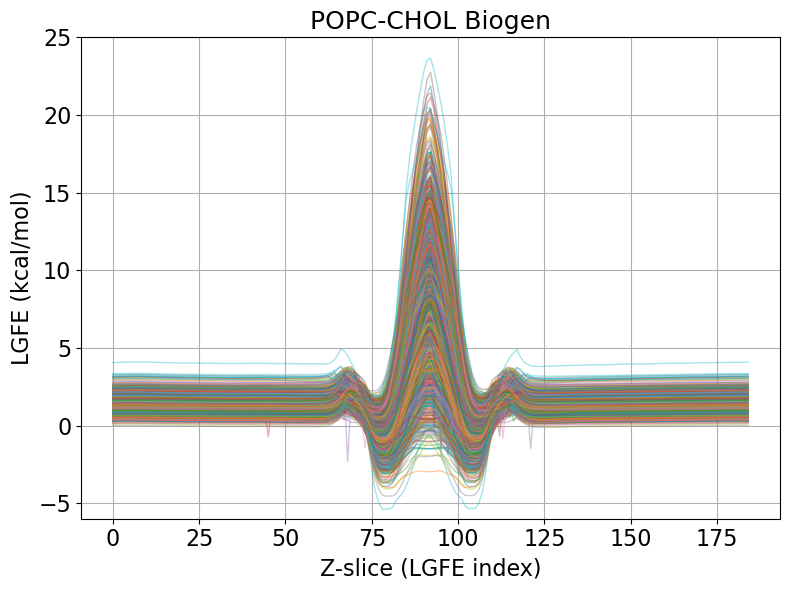

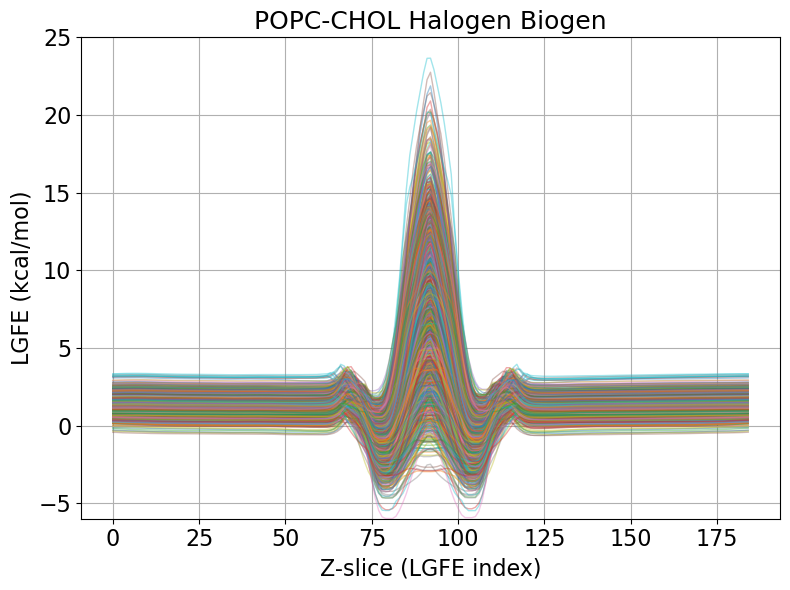

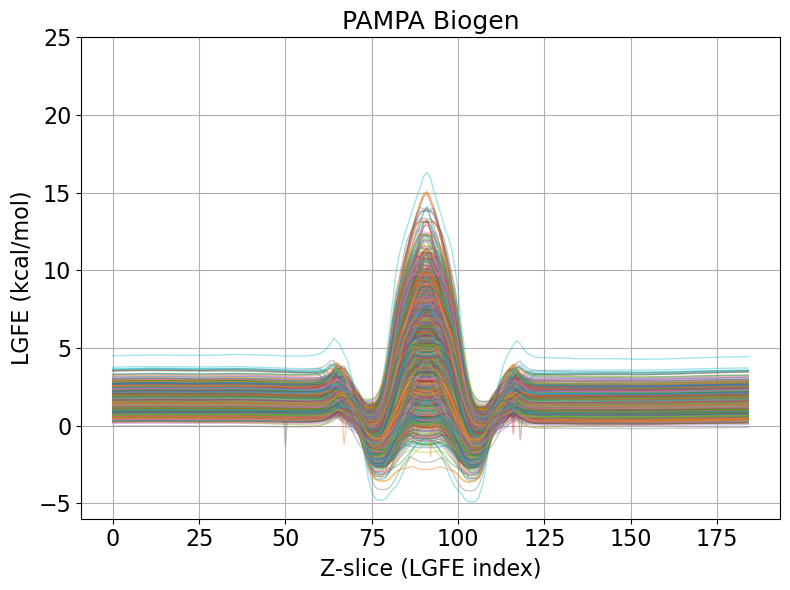

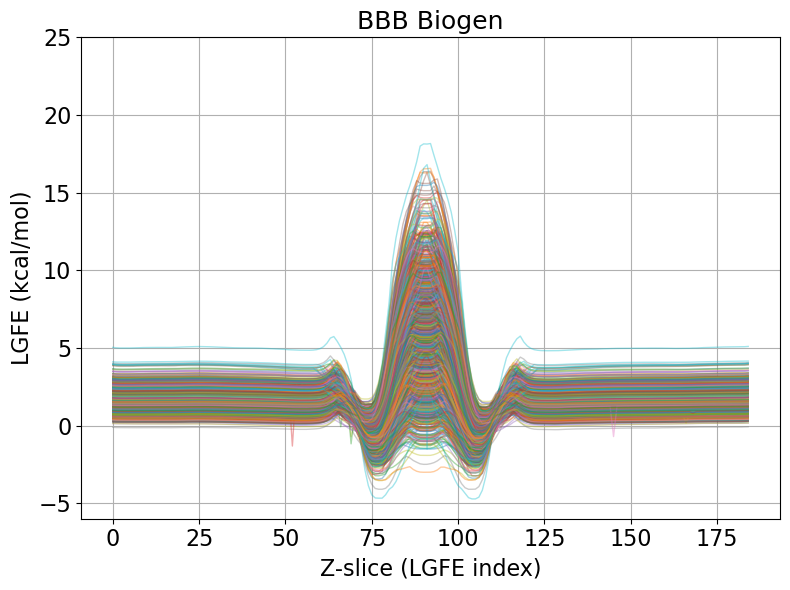

In [27]:
lgfe_popc_clean, lgfe_popc_sorted, df_popc_clean = plot_all(df_popc, memb_name="POPC-CHOL_Biogen")
lgfe_popc_halogen_clean, lgfe_popc_halogen_sorted, df_popc_halogen_clean = plot_all(df_popc_halogen, memb_name="POPC-CHOL_Halogen_Biogen")
lgfe_pampa_clean, lgfe_pampa_sorted, df_pampa_clean = plot_all(df_pampa, memb_name="PAMPA_Biogen")
lgfe_bbb_clean, lgfe_bbb_sorted, df_bbb_clean = plot_all(df_bbb, memb_name="BBB_Biogen")

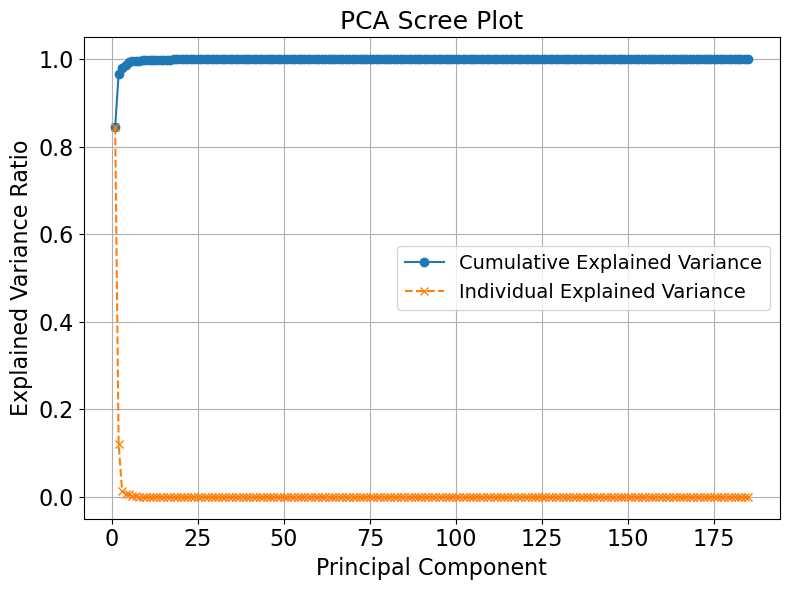

In [41]:
pca_full = PCA()
pca_full.fit(lgfe_popc_clean)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_variance, marker='o', label='Cumulative Explained Variance')
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='x', linestyle='--', label='Individual Explained Variance')
# plt.axhline(y=0.9, color='r', linestyle='--', label='90% Variance Threshold')
plt.xlabel('Principal Component',fontsize=16)
plt.ylabel('Explained Variance Ratio', fontsize=16)
plt.title('PCA Scree Plot', fontsize=18)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.savefig("./plots/pca_scree_plot_popc_biogen.png", dpi=300, bbox_inches="tight")
plt.show()
# --- 5. Dimensionality reduction for clustering and visualization ---
n_pca_components = 2  # Change to higher components if needed
pca = PCA(n_components=n_pca_components)
lgfe_pca_popc = pca.fit_transform(lgfe_popc_clean)

def scatter_pca(pca_data,  output_file, cluster_labels=None):
    # --- 7. 2D Scatter plot of PCA with clusters ---
    plt.figure(figsize=(8, 6))
    
    if cluster_labels is None:
        plt.scatter(pca_data[:, 0], pca_data[:, 1], c="black")
    else:
        cluster_labels = np.asarray(cluster_labels)

        # Separate POPC clusters and special labels
        popc_clusters = sorted({l for l in cluster_labels if l >= 0})
        special_labels = sorted({l for l in cluster_labels if l < 0})

        # Chose Dark2 colormap for distinct colors : If you plan to have more than 8 clusters,
        # consider using a different colormap or generating colors dynamically.
        cmap = cm.get_cmap("Dark2", 8)

        # Build color map dynamically
        color_map = {}

        # POPC clusters: dynamic colors
        for i, cl in enumerate(popc_clusters):
            color_map[cl] = cmap(i)

        # Special labels: fixed, semantic colors
        # color_map[-2] = "#FF0000FF"  # red = new, in-distribution
        color_map[-2] = "#000000"  # black = new, in-distribution
        color_map[-1] = "#000000"  # black = OOD

        # Plot each label separately (stable semantics)
        for label in popc_clusters + special_labels:
            mask = cluster_labels == label
            # marker = "s" if label == -1 else "o"

            plt.scatter(
                pca_data[mask, 0],
                pca_data[mask, 1],
                c=[color_map[label]],
                # s=60,
                # alpha=0.8,
                marker="x" if int(label) == -1 else "o",
                # edgecolors="white" if marker == "o" else None,
                edgecolors="white" if int(label) != -1 else None,
                # linewidths=0.4 if marker == "o" else None,
                linewidths=0.4 if int(label) != -1 else None,
                label=("New (OOD)" if label == -1 else
                    "New (in-distribution)" if label == -2 else
                    f"Cluster {label}")
            )

        plt.legend(fontsize=14)

    plt.xlabel("PC1", fontsize=16)
    plt.ylabel("PC2", fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    if not special_labels:
        plt.xlim([-50,60])
        plt.ylim([-20,40])
    else:
        plt.xlim([-50,70])
        plt.ylim([-30,90])

    # plt.title("KMeans Clustering of LGFE Profiles (PCA View)")
    plt.tight_layout()
    plt.savefig("./plots/"+ output_file, dpi=300, bbox_inches="tight")
    plt.close()



# --- 8. Plot average LGFE profile per cluster ---
def cluster_avg(df_clean, lgfe_sorted, output_file):
    plt.figure(figsize=(8, 6))
    # Chose Dark2 colormap for distinct colors : If you plan to have more than 8 clusters,
    # consider using a different colormap or generating colors dynamically.
    cmap = cm.get_cmap("Dark2", 8)
    # Build color map dynamically
    color_map = {}

    popc_clusters = sorted({l for l in df_clean["LGFE_Cluster"].unique() if l >= 0})

    # POPC clusters: dynamic colors
    for i, cl in enumerate(popc_clusters):
        color_map[cl] = cmap(i)

    for cluster_id in popc_clusters:
        cluster_mean = df_clean[df_clean["LGFE_Cluster"] == cluster_id][lgfe_sorted].mean()
        plt.plot(range(len(lgfe_sorted)), cluster_mean.values, label=f"Cluster {cluster_id}", color=cmap(cluster_id))

    plt.xlabel(r'Distance from simulation box edge ($\mathrm{\AA}$)',fontsize=16)
    plt.ylabel("Mean LGFE", fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    # plt.title("Mean LGFE Profiles per Cluster")
    plt.legend(fontsize=16)
    plt.ylim([-2.5,15])
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("./plots/"+ output_file, dpi=300, bbox_inches="tight")
    # plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.close()



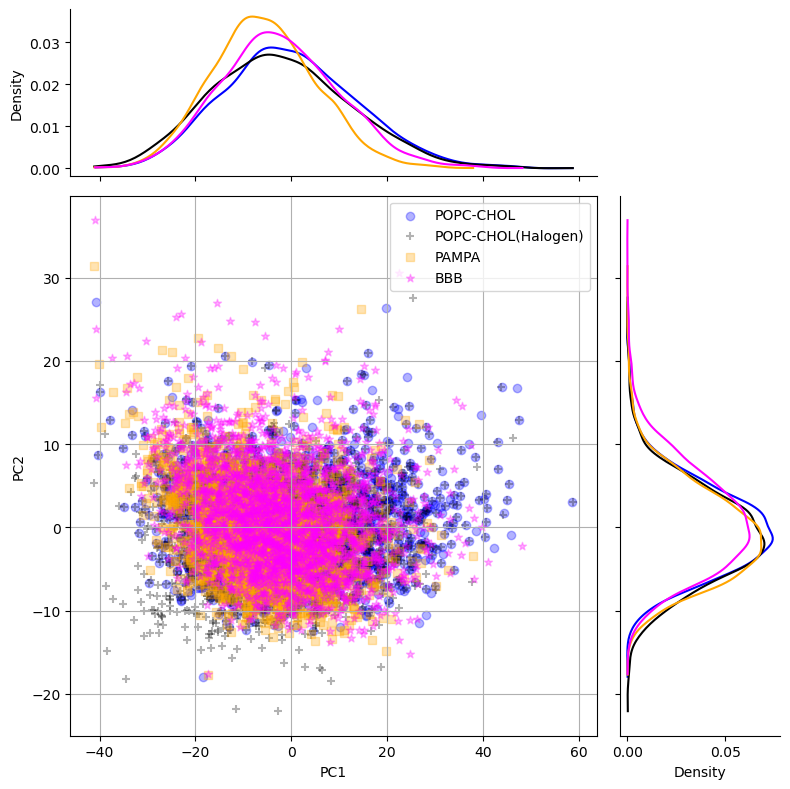

In [17]:
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
import numpy as np

# Function to plot KDE line
def plot_kde_line(ax, data, label, color, orientation='vertical'):
    kde = gaussian_kde(data)
    x = np.linspace(min(data), max(data), 200)
    y = kde(x)
    
    if orientation == 'vertical':
        ax.plot(x, y, label=label, color=color)
    else:
        ax.plot(y, x, label=label, color=color)

lgfe_pca_pampa = pca.transform(lgfe_pampa_clean)
lgfe_pca_bbb = pca.transform(lgfe_bbb_clean)
lgfe_pca_popc_halogen = pca.transform(lgfe_popc_halogen_clean)

# Setup figure with gridspec
fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(4, 4)

# Define colors
colors = {
    'POPC-CHOL': 'blue',
    'POPC-CHOL-halogen': 'black',
    'PAMPA': 'orange',
    'BBB': 'magenta',
}

ax_scatter = fig.add_subplot(gs[1:4, 0:3])
ax_scatter.scatter(lgfe_pca_popc[:, 0], lgfe_pca_popc[:, 1], label='POPC-CHOL', alpha=0.3, marker="o", c=colors['POPC-CHOL'])
ax_scatter.scatter(lgfe_pca_popc_halogen[:, 0], lgfe_pca_popc_halogen[:, 1], label='POPC-CHOL(Halogen)', alpha=0.3, marker="+",c=colors['POPC-CHOL-halogen'])
ax_scatter.scatter(lgfe_pca_pampa[:, 0], lgfe_pca_pampa[:, 1], label='PAMPA', alpha=0.3, marker="s", c=colors['PAMPA'])
ax_scatter.scatter(lgfe_pca_bbb[:, 0], lgfe_pca_bbb[:, 1], label='BBB', alpha=0.3, marker="*", c=colors['BBB'])
ax_scatter.set_xlabel("PC1")
ax_scatter.set_ylabel("PC2")
ax_scatter.legend()
ax_scatter.grid(True)


# Top PC1 Histogram (KDE line)
ax_histx = fig.add_subplot(gs[0, 0:3], sharex=ax_scatter)
plot_kde_line(ax_histx, lgfe_pca_popc[:, 0], 'POPC-CHOL', colors['POPC-CHOL'])
plot_kde_line(ax_histx, lgfe_pca_popc_halogen[:, 0], 'POPC-CHOL(Halogen)', colors['POPC-CHOL-halogen'])
plot_kde_line(ax_histx, lgfe_pca_pampa[:, 0], 'PAMPA', colors['PAMPA'])
plot_kde_line(ax_histx, lgfe_pca_bbb[:, 0], 'BBB', colors['BBB'])
ax_histx.tick_params(axis='x', labelbottom=False)
ax_histx.set_ylabel("Density")
ax_histx.spines['right'].set_visible(False)
ax_histx.spines['top'].set_visible(False)

# Right PC2 Histogram (KDE line)
ax_histy = fig.add_subplot(gs[1:4, 3], sharey=ax_scatter)
plot_kde_line(ax_histy, lgfe_pca_popc[:, 1], 'POPC-CHOL', colors['POPC-CHOL'], orientation='horizontal')
plot_kde_line(ax_histy, lgfe_pca_popc_halogen[:, 1], 'POPC-CHOL(Halogen)', colors['POPC-CHOL-halogen'], orientation='horizontal')
plot_kde_line(ax_histy, lgfe_pca_pampa[:, 1], 'PAMPA', colors['PAMPA'], orientation='horizontal')
plot_kde_line(ax_histy, lgfe_pca_bbb[:, 1], 'BBB', colors['BBB'], orientation='horizontal')
ax_histy.tick_params(axis='y', labelleft=False)
ax_histy.set_xlabel("Density")
ax_histy.spines['right'].set_visible(False)
ax_histy.spines['top'].set_visible(False)

# Finalize
# plt.suptitle("Projection of LGFE Profiles from Different Membranes onto Reference PCA", y=0.92)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.tight_layout()
plt.show()

In [43]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import pairwise_distances
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import numpy as np

# --- PCA fit on POPC ---
n_pca_components = 2
pca = PCA(n_components=n_pca_components)
lgfe_pca_popc = pca.fit_transform(lgfe_popc_clean)

# --- KMeans on POPC ---
n_clusters = 4
kmeans_popc = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels_popc = kmeans_popc.fit_predict(lgfe_popc_clean)
centroids_popc = kmeans_popc.cluster_centers_

df_popc_clean["LGFE_Cluster"] = cluster_labels_popc
scatter_pca(lgfe_pca_popc, "popc_pca.png", cluster_labels_popc)
cluster_avg(df_popc_clean, lgfe_popc_sorted, "popc_pca_cluster_mean.png")

# --- Function for projecting + aligning clusters ---
def project_and_align(data_clean, data_sorted, ref_centroids, name):
    # Project to POPC PCA space
    data_pca = pca.transform(data_clean)
    
    # Cluster in its own space
    kmeans_tmp = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels_tmp = kmeans_tmp.fit_predict(data_clean)
    centroids_tmp = kmeans_tmp.cluster_centers_
    
    # Align clusters to POPC
    dist_matrix = pairwise_distances(ref_centroids, centroids_tmp)
    row_ind, col_ind = linear_sum_assignment(dist_matrix)
    mapping = {col: row for row, col in zip(row_ind, col_ind)}
    labels_aligned = np.array([mapping[label] for label in cluster_labels_tmp])
    
    # Store & visualize
    globals()[f"df_{name}_clean"]["LGFE_Cluster"] = labels_aligned
    scatter_pca(data_pca,  f"{name}_pca.png", labels_aligned)
    cluster_avg(globals()[f"df_{name}_clean"], data_sorted, f"{name}_pca_cluster_mean.png")

# --- Project & align for other datasets ---
project_and_align(lgfe_popc_halogen_clean, lgfe_popc_halogen_sorted, centroids_popc, "popc_halogen")
project_and_align(lgfe_pampa_clean, lgfe_pampa_sorted, centroids_popc, "pampa")
project_and_align(lgfe_bbb_clean, lgfe_bbb_sorted, centroids_popc, "bbb")


/home/ashj/miniconda3/envs/memb-perm/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/tmp/ipykernel_20319/124718809.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("Dark2", 8)
/tmp/ipykernel_20319/124718809.py:102: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("Dark2", 8)
/home/ashj/miniconda3/envs/memb-perm/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default v

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_prominences, peak_widths

def peak_info(df_clean, lgfe_cols_sorted):

    peak_info_list = []

    for i, row in df_clean.iterrows():
        name = row["Name"]
        profile = row[lgfe_cols_sorted].values
        z = np.arange(len(profile))

        # --- Peaks ---
        peaks, peak_props = find_peaks(profile, prominence=0.5)
        prominences = peak_props["prominences"] if len(peaks) > 0 else []
        widths, width_heights, left_ips, right_ips = peak_widths(profile, peaks, rel_height=0.5) if len(peaks) > 0 else ([], [], [], [])

        # --- Troughs (inverted peaks) ---
        inverted = -profile
        troughs, trough_props = find_peaks(inverted, prominence=0.5)
        trough_prominences = trough_props["prominences"] if len(troughs) > 0 else []
        trough_widths, _, _, _ = peak_widths(inverted, troughs, rel_height=0.5) if len(troughs) > 0 else ([], [], [], [])

        # --- Summary ---
        entry = {
            "Name": name,
            "Number of Peaks": len(peaks),
            "Number of Troughs": len(troughs),
            "Absolute Height of Tallest Peak": profile[peaks].max() if len(peaks) > 0 else np.nan,
            "Maximum Peak Prominence": np.max(prominences) if len(prominences) > 0 else np.nan,
            "Full Width at Half Maximum (FWHM)": np.max(widths) if len(widths) > 0 else np.nan,
            "Absolute Depth of Deepest Trough": profile[troughs].min() if len(troughs) > 0 else np.nan,
            # "max_trough_prominence": np.max(trough_prominences) if len(trough_prominences) > 0 else np.nan,
            # "max_trough_width": np.max(trough_widths) if len(trough_widths) > 0 else np.nan,
            # "Peak to Trough Difference": (profile[peaks].max() - profile[troughs].min()) if (len(peaks) > 0 and len(troughs) > 0) else np.nan,
            # "Flat Region Mean": (np.mean(profile[:30]) + np.mean(profile[-30:])) / 2,  # Adjust slice range as needed
        }

        peak_info_list.append(entry)

    return (peak_info_list)


def plot_peak_info_histograms(all_peak_info, output_file):
    # Convert to DataFrames
    peak_info_dfs = {sys: pd.DataFrame(info) for sys, info in all_peak_info.items()}

    # Get properties to plot (assume all have same columns)
    properties = [col for col in peak_info_dfs[next(iter(peak_info_dfs))].columns if col != "Name"]

    n_cols = 3
    n_rows = -(-len(properties) // n_cols)  # ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 6 * n_rows))

    for ax, prop in zip(axes.flat, properties):
        for system, df in peak_info_dfs.items():
            data = df[prop].dropna()
            if prop in ["Number of Peaks", "Number of Troughs"]:
                bins = np.arange(int(data.max()) + 2)  # integer bins
                counts, _ = np.histogram(data, bins=bins)
                counts = counts / (counts.sum())

                # Shift bars for side-by-side plotting
                n_systems = len(peak_info_dfs)
                width = 0.8 / n_systems  # total width divided among systems
                system_idx = list(peak_info_dfs.keys()).index(system)  # 0,1,2,...

                ax.bar(bins[:-1] + (system_idx-2) * width, counts, width=width, label=system, alpha=0.8)
                ax.set_ylabel("Normalized Counts", fontsize=16)
                ax.set_xlabel("Number of Extrema", fontsize=16)
            elif prop in ["Full Width at Half Maximum (FWHM)"]:
                counts, bins = np.histogram(data, bins=20)
                counts = counts / (counts.sum() * np.diff(bins)[0])  # normalize to probability
                ax.plot(bins[:-1], counts, label=system, linewidth=3.5)
                ax.set_ylabel("Normalized Density", fontsize=16)
                ax.set_xlabel(r"Distance ($\mathrm{\AA}$)", fontsize=16)
            else:
                counts, bins = np.histogram(data, bins=20)
                counts = counts / (counts.sum() * np.diff(bins)[0])  # normalize to probability
                ax.plot(bins[:-1], counts, label=system, linewidth=3.5)
                ax.set_ylabel("Normalized Density", fontsize=16)
                ax.set_xlabel(r"$\mathrm{\Delta}$LGFE (kcal/mol)", fontsize=16)

        # ax.legend().remove()  # remove legends from individual subplots
        ax.legend(fontsize=16)
        ax.set_title(prop, fontsize=18)
        ax.tick_params(axis='x', labelsize=16)
        ax.tick_params(axis='y', labelsize=16)     
        ax.grid(True)  
        
    # Hide unused axes
    for ax in axes.flat[len(properties):]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.close()


# --- Create final DataFrame ---
# peak_info_df = pd.DataFrame(peak_info_list)
# peak_info_df.head()


In [45]:
all_peak_info = {
    "POPC-CHOL": peak_info(df_popc_clean, lgfe_popc_sorted),
    "POPC-CHOL(Halogen)": peak_info(df_popc_halogen_clean, lgfe_popc_halogen_sorted),
    "PAMPA": peak_info(df_pampa_clean, lgfe_pampa_sorted),
    "BBB": peak_info(df_bbb_clean, lgfe_bbb_sorted)
}

In [21]:
plot_peak_info_histograms(all_peak_info, "./plots/peak_summary_stats.png")

## Independant datasets

In [47]:
def project_only(data_clean, name, output_dir="."):
    """
    Project new LGFE data into the POPC PCA space and visualize where it lands.

    Parameters
    ----------
    data_clean : np.ndarray
        LGFE feature matrix (same columns/order as POPC training data)
    name : str
        Dataset name used for output filename
    output_dir : str
        Directory to save PCA plot

    Returns
    -------
    data_pca : np.ndarray
        2D PCA coordinates in POPC PCA space
    """
    # Project into POPC PCA space
    data_pca = pca.transform(data_clean)

    # Plot (no clustering, single color)
    outfile = f"{output_dir}/{name}_pca.png"
    scatter_pca(data_pca, cluster_labels=None, output_file=outfile)

    return data_pca

def overlay_on_popc_pca(
    lgfe_popc_clean,
    cluster_labels_popc,
    lgfe_new_clean,
    pca,
    output_file,
    new_label=-1
):
    """
    Overlay a new dataset onto POPC PCA space.

    POPC points are colored by their cluster labels.
    New points are plotted as a separate group (label = new_label).

    Parameters
    ----------
    lgfe_popc_clean : np.ndarray
        POPC LGFE feature matrix (used only for projection)
    cluster_labels_popc : np.ndarray
        POPC cluster labels
    lgfe_new_clean : np.ndarray
        New LGFE feature matrix (out-of-sample)
    pca : sklearn.decomposition.PCA
        PCA object fit on POPC
    output_file : str
        Output image filename
    new_label : int
        Label assigned to new data points (default = -1)
    """

    # Project both datasets into POPC PCA space
    popc_pca = pca.transform(lgfe_popc_clean)
    new_pca = pca.transform(lgfe_new_clean)

    # Stack data
    X = np.vstack([popc_pca, new_pca])
    labels = np.concatenate([
        cluster_labels_popc,
        np.full(len(new_pca), new_label)
    ])

    # Plot
    scatter_pca(X, output_file, labels)

    return popc_pca, new_pca

from sklearn.metrics import pairwise_distances

# Compute POPC reference distances

# Distance of each POPC point to its assigned centroid
popc_distances = pairwise_distances(
    lgfe_popc_clean,
    centroids_popc
)

assigned_popc_dist = popc_distances[
    np.arange(len(lgfe_popc_clean)),
    cluster_labels_popc
]

# Choose an OOD threshold
ood_threshold = np.percentile(assigned_popc_dist, 95)

# Flag OOD points for a new dataset
def flag_ood(data_clean, centroids, threshold):
    """
    Flag points that are far from POPC cluster centroids.

    Returns
    -------
    min_dist : np.ndarray
        Distance to nearest POPC centroid
    is_ood : np.ndarray (bool)
        True if point is out-of-distribution
    """
    dists = pairwise_distances(data_clean, centroids)
    min_dist = dists.min(axis=1)
    is_ood = min_dist > threshold

    return min_dist, is_ood

def overlay_with_ood_detection(
    lgfe_popc_clean,
    cluster_labels_popc,
    lgfe_new_clean,
    pca,
    centroids,
    ood_threshold,
    output_file
):
    """
    Overlay a new dataset onto POPC PCA space with OOD detection.

    POPC points are colored by their cluster labels.
    New points are colored by OOD status.

    Parameters
    ----------
    lgfe_popc_clean : np.ndarray
        POPC LGFE feature matrix (used only for projection)
    cluster_labels_popc : np.ndarray
        POPC cluster labels
    lgfe_new_clean : np.ndarray
        New LGFE feature matrix (out-of-sample)
    pca : sklearn.decomposition.PCA
        PCA object fit on POPC
    centroids : np.ndarray
        POPC cluster centroids
    ood_threshold : float
        Distance threshold for OOD detection
    output_file : str
        Output image filename
    """

    # Project both datasets into POPC PCA space
    popc_pca = pca.transform(lgfe_popc_clean)
    new_pca = pca.transform(lgfe_new_clean)

    # Flag OOD points in new data
    _, is_ood = flag_ood(lgfe_new_clean, centroids, ood_threshold)

    # Stack data
    X = np.vstack([popc_pca, new_pca])
    labels = np.concatenate([
        cluster_labels_popc,
        np.where(is_ood, -1, -2)  # -1 for OOD, -2 for in-distribution
    ])

    # Plot
    scatter_pca(X, output_file, labels)

    return popc_pca, new_pca, is_ood

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist


def cluster_distance_table(
    lgfe_new_clean,
    ligand_names,
    centroids,
    ood_threshold,
    output_csv
):
    """
    Compute distance to every POPC cluster centroid, min distance,
    and OOD flag for each ligand.

    Parameters
    ----------
    lgfe_new_clean : np.ndarray (N, D)
        New ligand feature matrix
    ligand_names : list[str]
        Ligand identifiers
    centroids : np.ndarray (K, D)
        POPC cluster centroids
    ood_threshold : float
        Distance threshold for OOD
    output_csv : str
        Output CSV filename
    """

    # Distances: (N_ligands, N_clusters)
    dists = cdist(lgfe_new_clean, centroids)

    # Minimum distance per ligand
    min_dist = dists.min(axis=1)

    # OOD flag
    is_ood = min_dist > ood_threshold

    # Build DataFrame
    df = pd.DataFrame(
        dists,
        columns=[f"dist_cluster_{i}" for i in range(dists.shape[1])]
    )

    df.insert(0, "ligand", ligand_names)
    df["min_distance"] = min_dist
    df["is_ood"] = is_ood

    df.to_csv(output_csv, index=False)
    return df


In [29]:
df_ind_1 = pd.read_csv("../data/popc-chol-MDCK-MDR1-Hellinger-P_app_lgfe.csv")
df_ind_2 = pd.read_csv("../data/popc-chol-MDCK-Irvine-P_app_lgfe.csv")
df_ind_3 = pd.read_csv("../data/popc-chol-MDCK-MDR1-QWang-P_app_lgfe.csv")
df_ind_4 = pd.read_csv("../data/popc-chol-MDCK-MDR1-Summerfield-P_app_lgfe.csv")
df_ind_5 = pd.read_csv("../data/popc-chol-cMdr1_KO_MDCK1-beran-P_app_lgfe.csv")

No outliers detected.
No outliers detected.
No outliers detected.
No outliers detected.
No outliers detected.


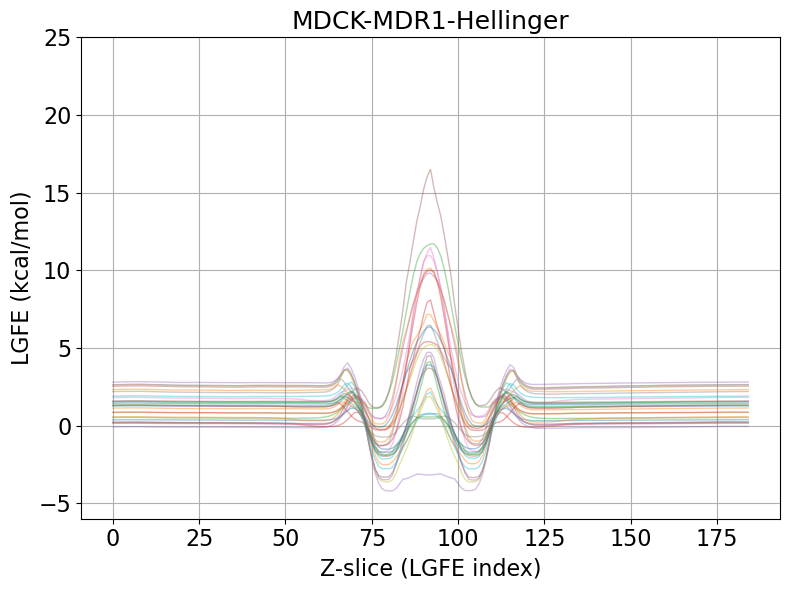

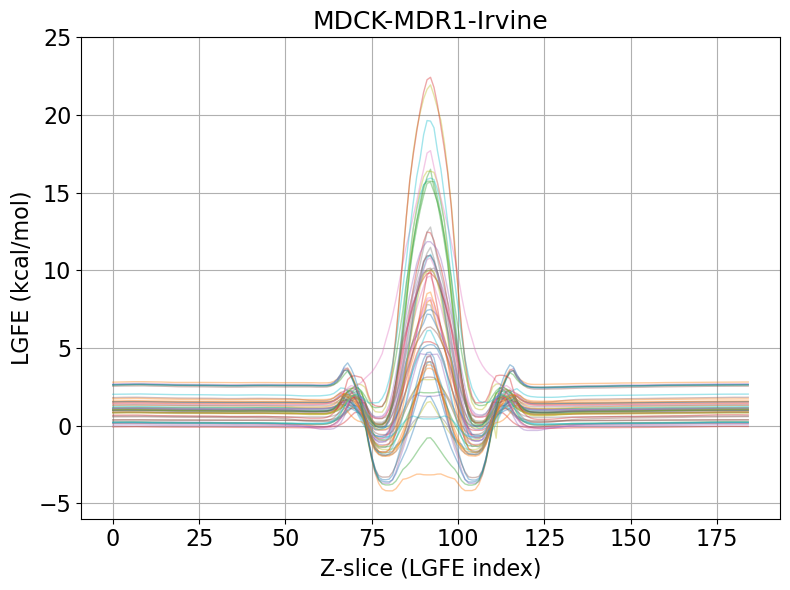

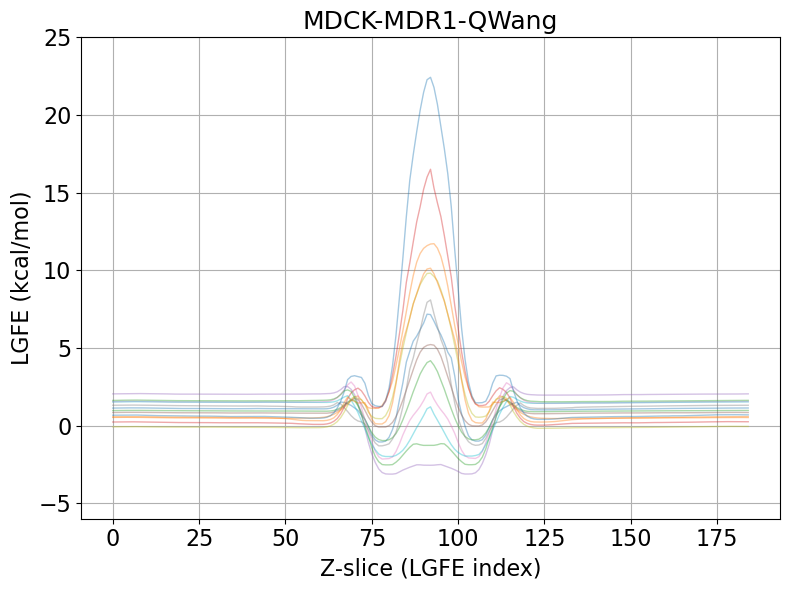

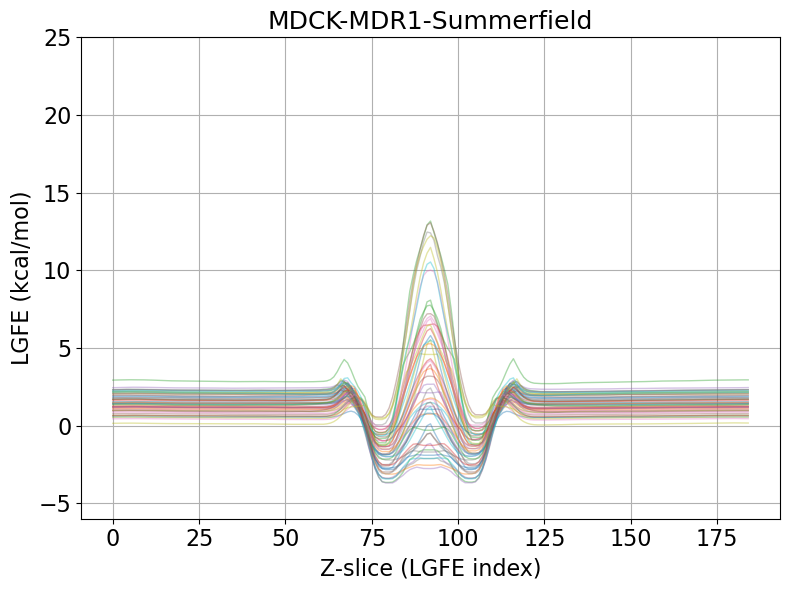

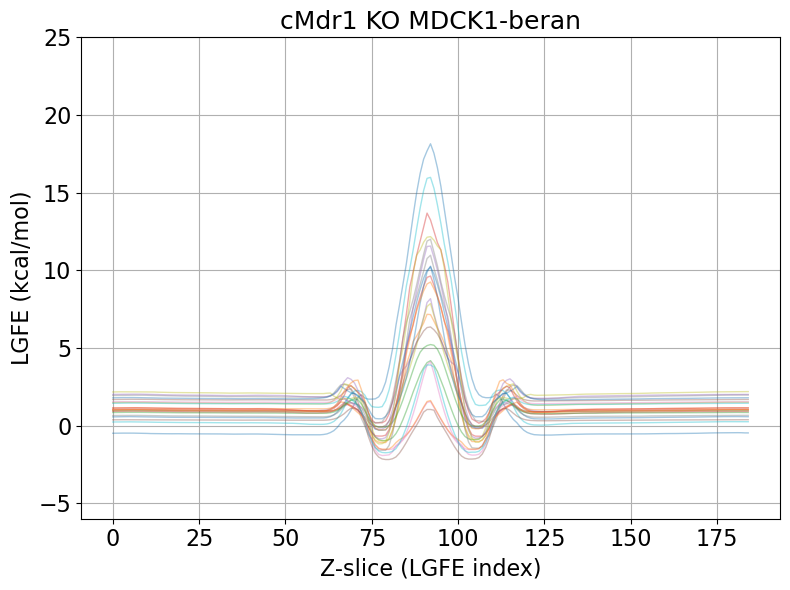

In [30]:
lgfe_ind_1_clean, lgfe_ind_1_sorted, df_MDCK_MDR1_Hellinger_clean = plot_all(df_ind_1, memb_name="MDCK-MDR1-Hellinger")
lgfe_ind_2_clean, lgfe_ind_2_sorted, df_MDCK_MDR1_Irvine_clean = plot_all(df_ind_2, memb_name="MDCK-MDR1-Irvine")
lgfe_ind_3_clean, lgfe_ind_3_sorted, df_MDCK_MDR1_QWang_clean = plot_all(df_ind_3, memb_name="MDCK-MDR1-QWang")
lgfe_ind_4_clean, lgfe_ind_4_sorted, df_MDCK_MDR1_Summerfield_clean = plot_all(df_ind_4, memb_name="MDCK-MDR1-Summerfield")
lgfe_ind_5_clean, lgfe_ind_5_sorted, df_cMdr1_KO_MDCK1_beran_clean = plot_all(df_ind_5, memb_name="cMdr1_KO_MDCK1-beran")

In [32]:
overlay_with_ood_detection(
    lgfe_popc_clean=lgfe_popc_clean,
    cluster_labels_popc=cluster_labels_popc,
    lgfe_new_clean=lgfe_ind_1_clean,
    pca=pca,
    centroids=centroids_popc,
    ood_threshold=ood_threshold,
    output_file="popc_with_MDCK_MDR1_Hellinger_ood.png"
)
overlay_with_ood_detection(
    lgfe_popc_clean=lgfe_popc_clean,
    cluster_labels_popc=cluster_labels_popc,
    lgfe_new_clean=lgfe_ind_2_clean,
    pca=pca,
    centroids=centroids_popc,
    ood_threshold=ood_threshold,
    output_file="popc_with_MDCK_MDR1_Irvine_ood.png"
)
overlay_with_ood_detection(
    lgfe_popc_clean=lgfe_popc_clean,
    cluster_labels_popc=cluster_labels_popc,
    lgfe_new_clean=lgfe_ind_3_clean,
    pca=pca,
    centroids=centroids_popc,
    ood_threshold=ood_threshold,
    output_file="popc_with_MDCK_MDR1_QWang_ood.png"
)
overlay_with_ood_detection(
    lgfe_popc_clean=lgfe_popc_clean,
    cluster_labels_popc=cluster_labels_popc,
    lgfe_new_clean=lgfe_ind_4_clean,
    pca=pca,
    centroids=centroids_popc,
    ood_threshold=ood_threshold,
    output_file="popc_with_MDCK_MDR1_Summerfield_ood.png"
)
overlay_with_ood_detection(
    lgfe_popc_clean=lgfe_popc_clean,
    cluster_labels_popc=cluster_labels_popc,
    lgfe_new_clean=lgfe_ind_5_clean,
    pca=pca,
    centroids=centroids_popc,
    ood_threshold=ood_threshold,
    output_file="popc_with_cMdr1_KO_MDCK1_beran_ood.png"
)


/tmp/ipykernel_20319/3776484016.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("Dark2", 8)
/tmp/ipykernel_20319/3776484016.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("Dark2", 8)
/tmp/ipykernel_20319/3776484016.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("Dark2", 8)
/tmp/ipykernel_20319/3776484016.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will 

(array([[ -5.89323152,  -8.72054619],
        [ 23.93859488,   2.17534357],
        [ -6.48377447,   5.10525668],
        ...,
        [  2.52940613,  -6.45832285],
        [-11.39775987,  -3.35873101],
        [ -4.16846278,  -5.18736269]]),
 array([[ 41.61331132, -14.50357143],
        [ -1.29960318,  -2.50628692],
        [-12.14338616,  -6.6747413 ],
        [  6.1973396 ,  -3.48864324],
        [  1.26966911,  -4.23537719],
        [-24.98525384,  -0.28753149],
        [-21.55669662,  -8.03035611],
        [  6.26765867,   9.52409589],
        [ -2.48056116,   1.59980068],
        [ 30.86561869,  -7.52720757],
        [ 10.57994446,  -7.53451062],
        [-21.19203668,  -8.0054759 ],
        [ -5.50801945,  -7.655475  ],
        [ 19.74102621,   1.42758582],
        [  8.24379994,  10.12106799],
        [ -0.15640535, -11.95979914],
        [-18.26895507,  -0.56936233],
        [ 15.5377416 ,  -5.47575086],
        [ 14.12346968,  12.29398098],
        [-16.70859701,  -1.30303401

In [48]:
cluster_distance_table(
    lgfe_new_clean=lgfe_ind_1_clean,
    ligand_names=df_MDCK_MDR1_Hellinger_clean["Molecule"].tolist(),
    centroids=centroids_popc,
    ood_threshold=ood_threshold,
    output_csv="./plots/MDCK_MDR1_Hellinger_distance_table.csv"
)

,ligand,dist_cluster_0,dist_cluster_1,dist_cluster_2,dist_cluster_3,min_distance,is_ood
0,Diazepam,45.648842,17.100362,29.429944,7.668205,7.668205,False
1,Atenolol,24.849760,5.882427,9.107389,18.665416,5.882427,False
2,Caffeine,9.282302,26.662857,14.952800,40.244863,9.282302,False
3,Salicylic_Acid,32.162035,14.801217,18.691666,22.889851,14.801217,True
4,Progesterone,65.573529,38.235537,50.183020,24.822538,24.822538,True
5,Furosemide,12.757725,37.816974,25.690416,51.447665,12.757725,True
6,Lisinopril,20.564743,15.303526,11.147324,25.633751,11.147324,False
7,Risperidone,30.157101,10.296231,16.367852,15.065374,10.296231,False
8,Antipyrine,30.236410,6.810327,14.539142,16.254601,6.810327,False
9,Rhodamine_123,44.359765,15.791498,28.241988,4.171127,4.171127,False


In [33]:
df_cyc_1 = pd.read_csv("../data/popc-chol-cyclic-peptide-Source_2015_Lewis.csv")
df_cyc_2 = pd.read_csv("../data/popc-chol-cyclic-peptide-Source_2016_Fouché.csv")
df_cyc_3 = pd.read_csv("../data/popc-chol-cyclic-peptide-Source_2016_Schwochert.csv")
df_cyc_4 = pd.read_csv("../data/popc-chol-cyclic-peptide-Source_2020_Furukawa.csv")
df_cyc_5 = pd.read_csv("../data/popc-chol-cyclic-peptide-Source_2021_Kelly.csv")
df_cyc_6 = pd.read_csv("../data/popc-chol-cyclic-peptide-Source_2024_Faris.csv")

No outliers detected.
No outliers detected.
No outliers detected.
No outliers detected.
No outliers detected.
No outliers detected.


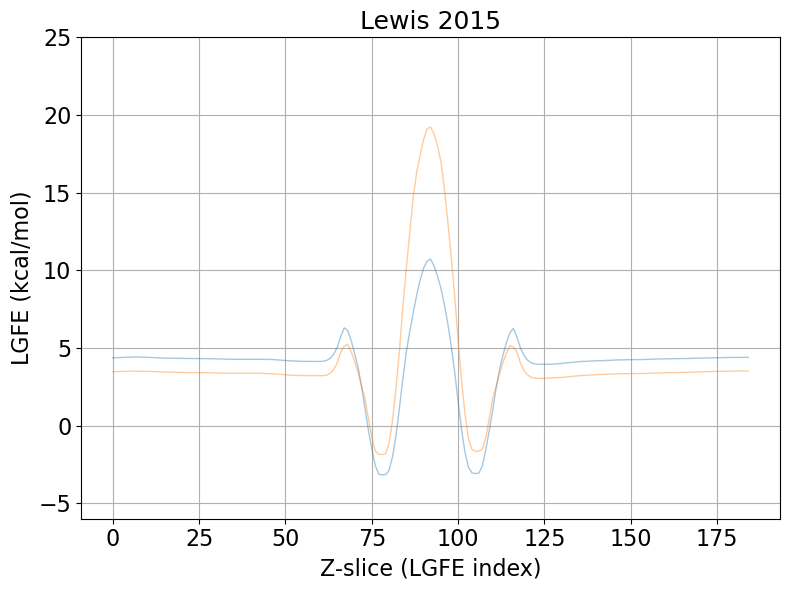

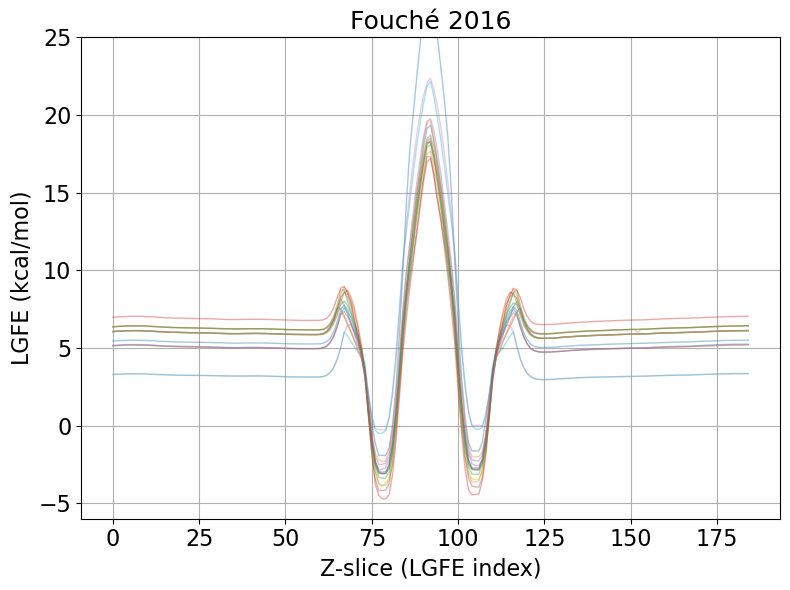

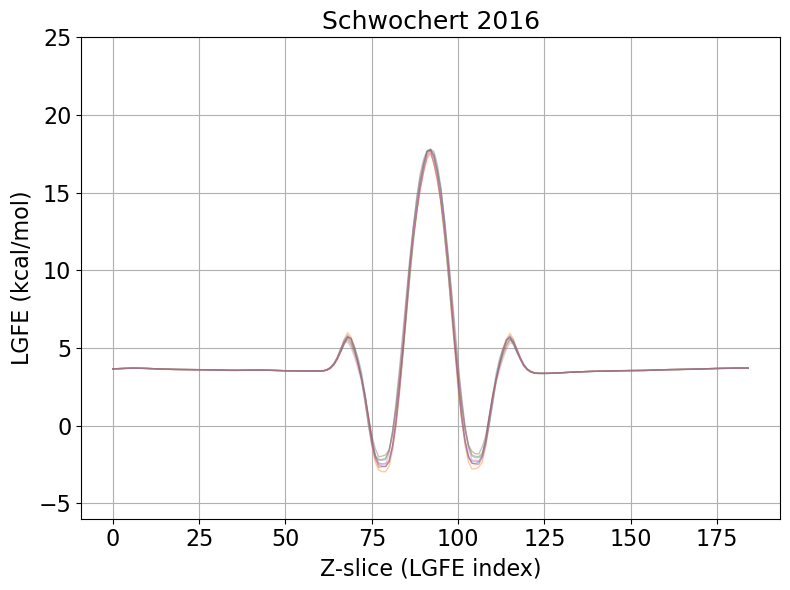

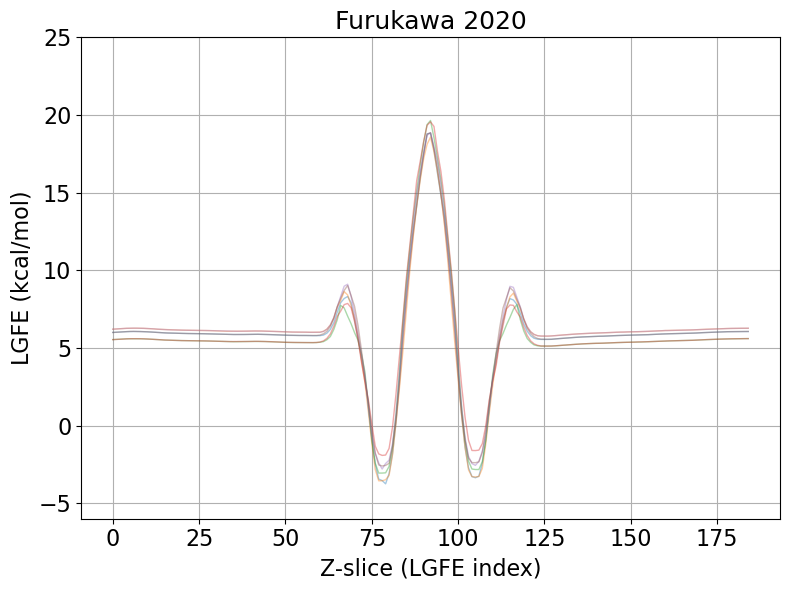

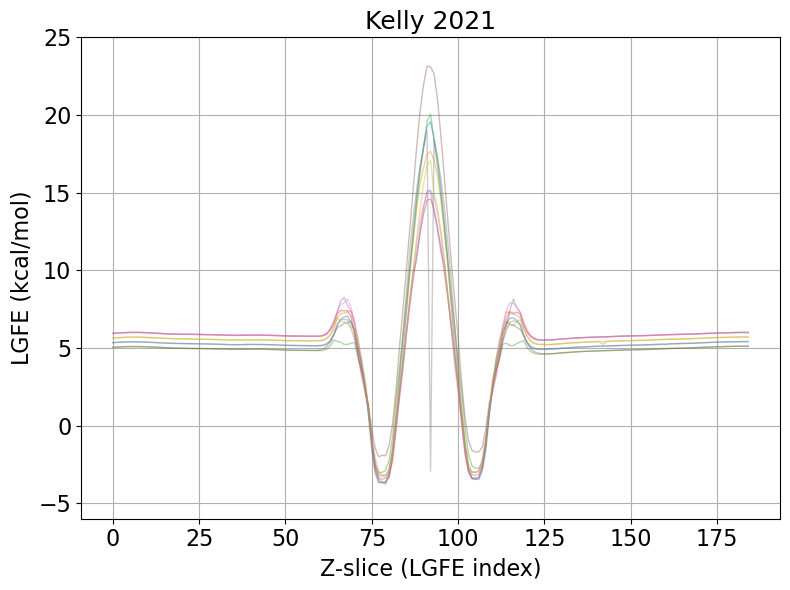

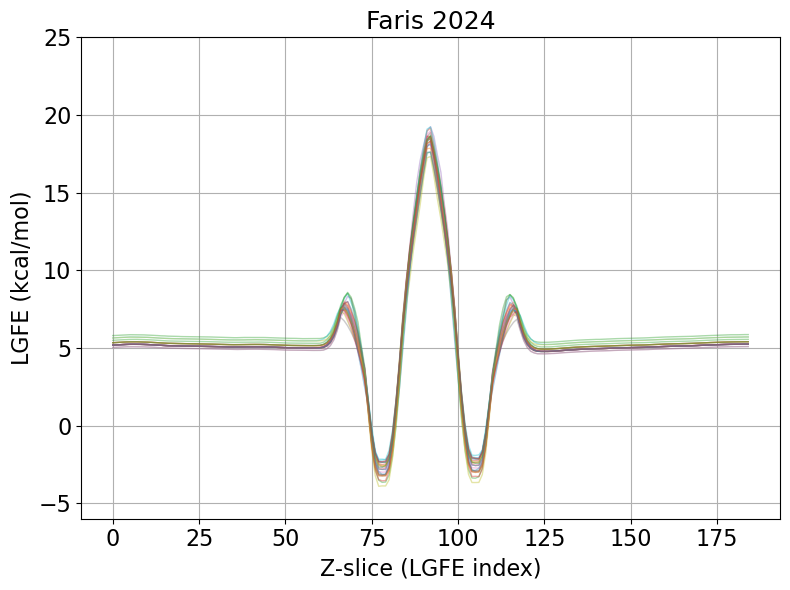

In [34]:
lgfe_cyc_1_clean, lgfe_cyc_1_sorted, df_cyc_1_clean = plot_all(df_cyc_1, memb_name="Lewis 2015")
lgfe_cyc_2_clean, lgfe_cyc_2_sorted, df_cyc_2_clean = plot_all(df_cyc_2, memb_name="Fouché 2016")
lgfe_cyc_3_clean, lgfe_cyc_3_sorted, df_cyc_3_clean = plot_all(df_cyc_3, memb_name="Schwochert 2016")
lgfe_cyc_4_clean, lgfe_cyc_4_sorted, df_cyc_4_clean = plot_all(df_cyc_4, memb_name="Furukawa 2020")
lgfe_cyc_5_clean, lgfe_cyc_5_sorted, df_cyc_5_clean = plot_all(df_cyc_5, memb_name="Kelly 2021")
lgfe_cyc_6_clean, lgfe_cyc_6_sorted, df_cyc_6_clean = plot_all(df_cyc_6, memb_name="Faris 2024")

In [38]:
overlay_with_ood_detection(
    lgfe_popc_clean=lgfe_popc_clean,
    cluster_labels_popc=cluster_labels_popc,
    lgfe_new_clean=lgfe_cyc_1_clean,
    pca=pca,
    centroids=centroids_popc,
    ood_threshold=ood_threshold,
    output_file="popc_with_cyclic_peptide_Lewis_2015_ood.png"
)
overlay_with_ood_detection(
    lgfe_popc_clean=lgfe_popc_clean,
    cluster_labels_popc=cluster_labels_popc,
    lgfe_new_clean=lgfe_cyc_2_clean,
    pca=pca,
    centroids=centroids_popc,
    ood_threshold=ood_threshold,
    output_file="popc_with_cyclic_peptide_Fouché_2016_ood.png"
)
overlay_with_ood_detection(
    lgfe_popc_clean=lgfe_popc_clean,
    cluster_labels_popc=cluster_labels_popc,
    lgfe_new_clean=lgfe_cyc_3_clean,
    pca=pca,
    centroids=centroids_popc,
    ood_threshold=ood_threshold,
    output_file="popc_with_cyclic_peptide_Schwochert_2016_ood.png"
)
overlay_with_ood_detection(
    lgfe_popc_clean=lgfe_popc_clean,
    cluster_labels_popc=cluster_labels_popc,
    lgfe_new_clean=lgfe_cyc_4_clean,
    pca=pca,
    centroids=centroids_popc,
    ood_threshold=ood_threshold,
    output_file="popc_with_cyclic_peptide_Furukawa_2020_ood.png"
)
overlay_with_ood_detection(
    lgfe_popc_clean=lgfe_popc_clean,
    cluster_labels_popc=cluster_labels_popc,
    lgfe_new_clean=lgfe_cyc_5_clean,
    pca=pca,
    centroids=centroids_popc,
    ood_threshold=ood_threshold,
    output_file="popc_with_cyclic_peptide_Kelly_2021_ood.png"
)
overlay_with_ood_detection(
    lgfe_popc_clean=lgfe_popc_clean,
    cluster_labels_popc=cluster_labels_popc,
    lgfe_new_clean=lgfe_cyc_6_clean,
    pca=pca,
    centroids=centroids_popc,
    ood_threshold=ood_threshold,
    output_file="popc_with_cyclic_peptide_Faris_2024_ood.png"
)

/tmp/ipykernel_20319/233414061.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("Dark2", 8)
/tmp/ipykernel_20319/233414061.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("Dark2", 8)
/tmp/ipykernel_20319/233414061.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap("Dark2", 8)
/tmp/ipykernel_20319/233414061.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be r

(array([[ -5.89323152,  -8.72054619],
        [ 23.93859488,   2.17534357],
        [ -6.48377447,   5.10525668],
        ...,
        [  2.52940613,  -6.45832285],
        [-11.39775987,  -3.35873101],
        [ -4.16846278,  -5.18736269]]),
 array([[19.25387604, 54.55872771],
        [23.4935644 , 53.54623447],
        [15.19470184, 59.1244079 ],
        [22.57279551, 52.94780042],
        [24.73407887, 53.96663199],
        [21.68618093, 53.41000049],
        [20.14163095, 50.57629692],
        [19.62364489, 50.68678739],
        [20.05881878, 52.21928265],
        [20.07272299, 57.83967633],
        [19.24546655, 52.6984004 ],
        [19.08817849, 53.64100342],
        [22.81803751, 56.58576348],
        [20.69958936, 53.52725217],
        [22.04397312, 52.67829434],
        [20.56315624, 55.02512007],
        [21.27921153, 52.98082304],
        [20.31289546, 53.08042463],
        [13.90995507, 57.06900518],
        [23.14232075, 52.8771399 ],
        [18.48383335, 51.89755566],
 

In [76]:
df_ind_1 = pd.read_csv("../data/pampa-MDCK-MDR1-Hellinger-P_app_lgfe.csv")
df_ind_2 = pd.read_csv("../data/pampa-MDCK-Irvine-P_app_lgfe.csv")
df_ind_3 = pd.read_csv("../data/pampa-MDCK-MDR1-QWang-P_app_lgfe.csv")
df_ind_4 = pd.read_csv("../data/pampa-MDCK-MDR1-Summerfield-P_app_lgfe.csv")
df_ind_5 = pd.read_csv("../data/pampa-cMdr1_KO_MDCK1-beran-P_app_lgfe.csv")

No outliers detected.


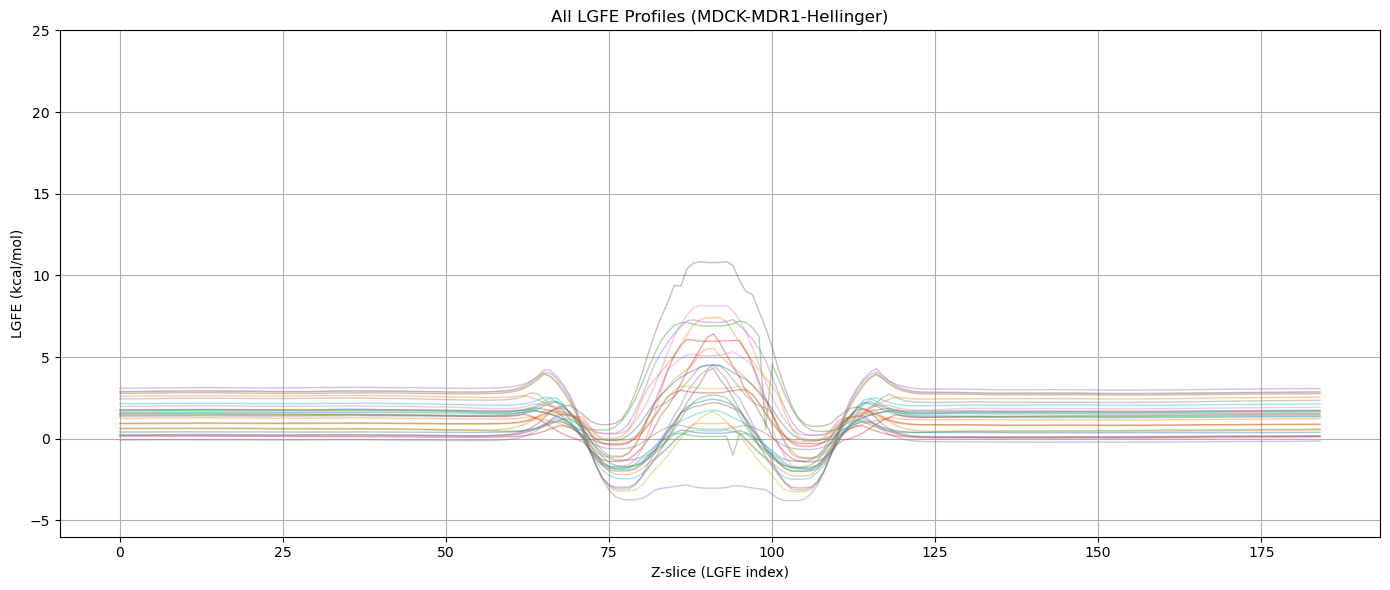

No outliers detected.


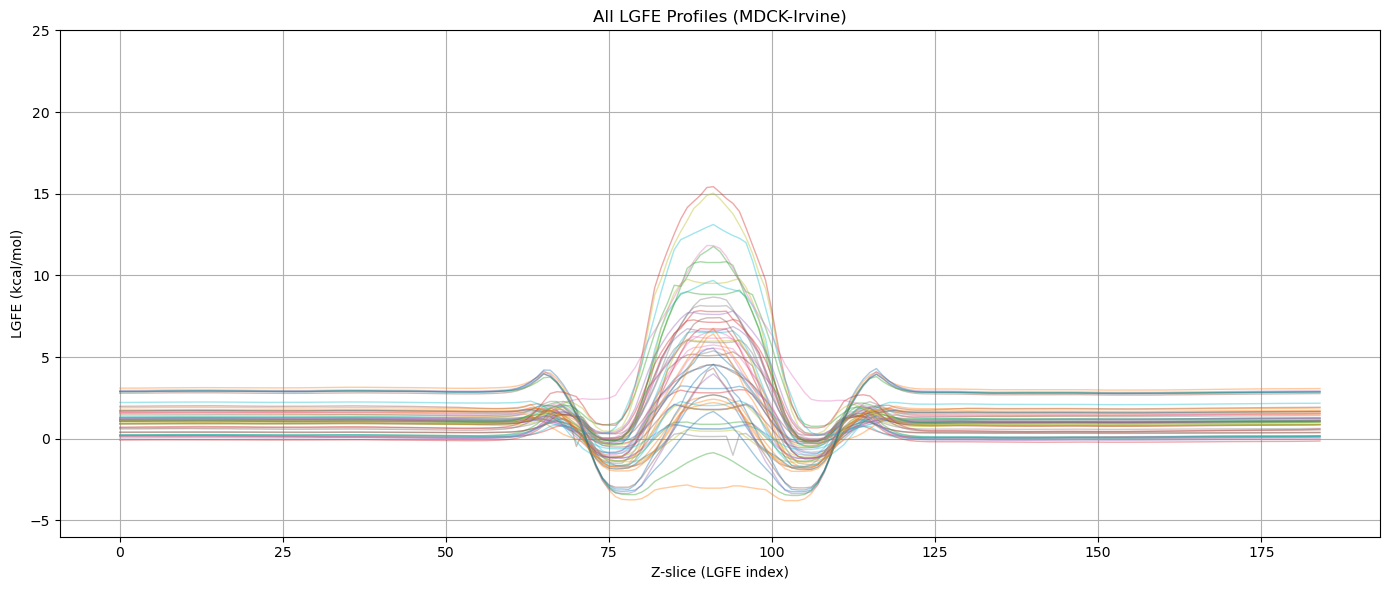

No outliers detected.


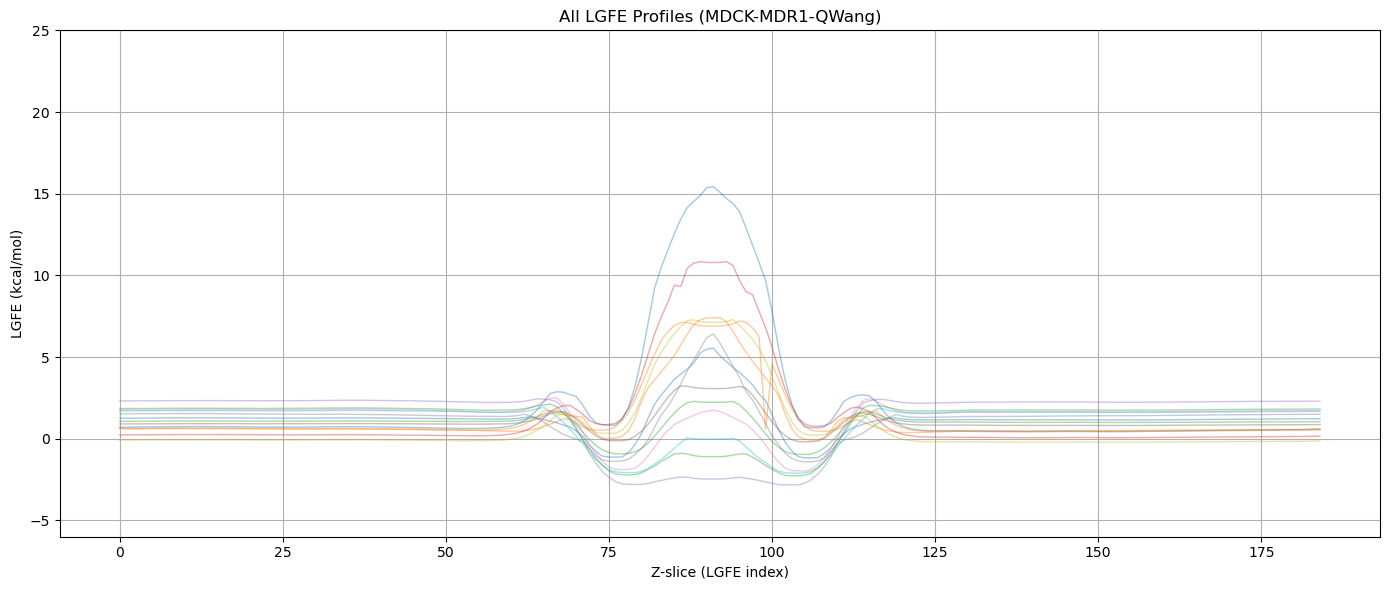

No outliers detected.


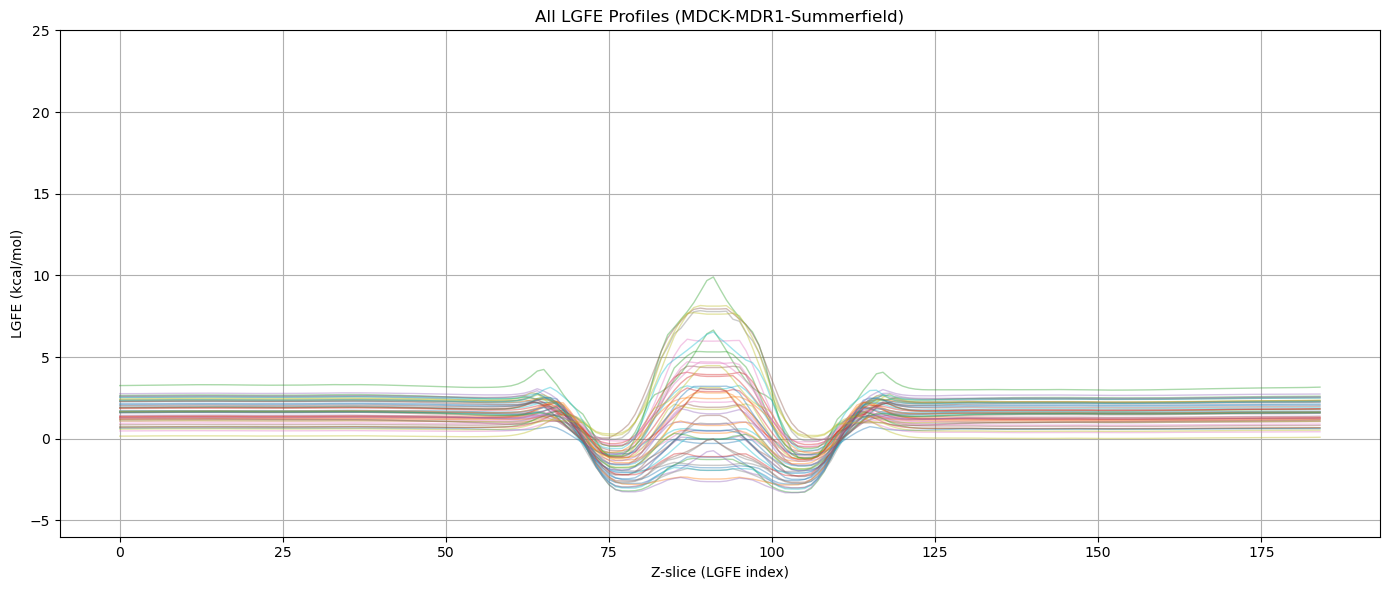

No outliers detected.


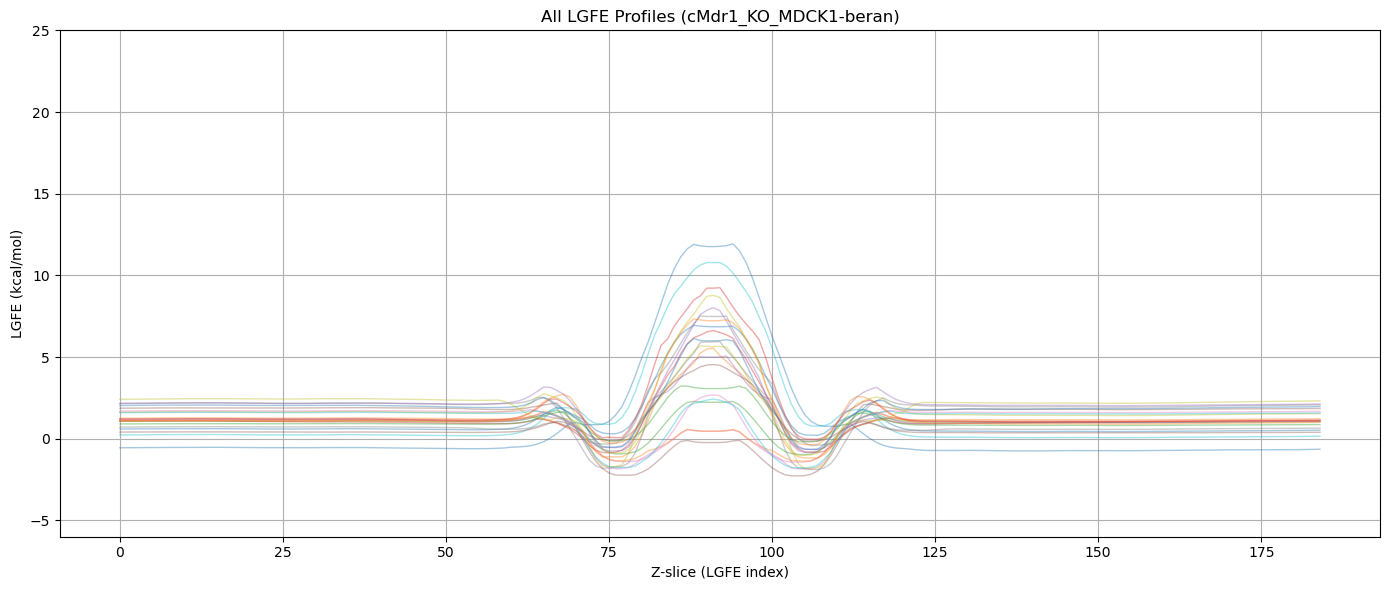

In [77]:
lgfe_ind_1_clean, lgfe_ind_1_sorted, df_ind_1_clean = plot_all(df_ind_1, memb_name="MDCK-MDR1-Hellinger")
lgfe_ind_2_clean, lgfe_ind_2_sorted, df_ind_2_clean = plot_all(df_ind_2, memb_name="MDCK-Irvine")
lgfe_ind_3_clean, lgfe_ind_3_sorted, df_ind_3_clean = plot_all(df_ind_3, memb_name="MDCK-MDR1-QWang")
lgfe_ind_4_clean, lgfe_ind_4_sorted, df_ind_4_clean = plot_all(df_ind_4, memb_name="MDCK-MDR1-Summerfield")
lgfe_ind_5_clean, lgfe_ind_5_sorted, df_ind_5_clean = plot_all(df_ind_5, memb_name="cMdr1_KO_MDCK1-beran")

In [78]:
df_cyc_1 = pd.read_csv("../data/pampa-cyclic-peptide-Source_2015_Lewis.csv")
df_cyc_2 = pd.read_csv("../data/pampa-cyclic-peptide-Source_2016_Fouché.csv")
df_cyc_3 = pd.read_csv("../data/pampa-cyclic-peptide-Source_2016_Schwochert.csv")
df_cyc_4 = pd.read_csv("../data/pampa-cyclic-peptide-Source_2020_Furukawa.csv")
df_cyc_5 = pd.read_csv("../data/pampa-cyclic-peptide-Source_2021_Kelly.csv")
df_cyc_6 = pd.read_csv("../data/pampa-cyclic-peptide-Source_2024_Faris.csv")

No outliers detected.


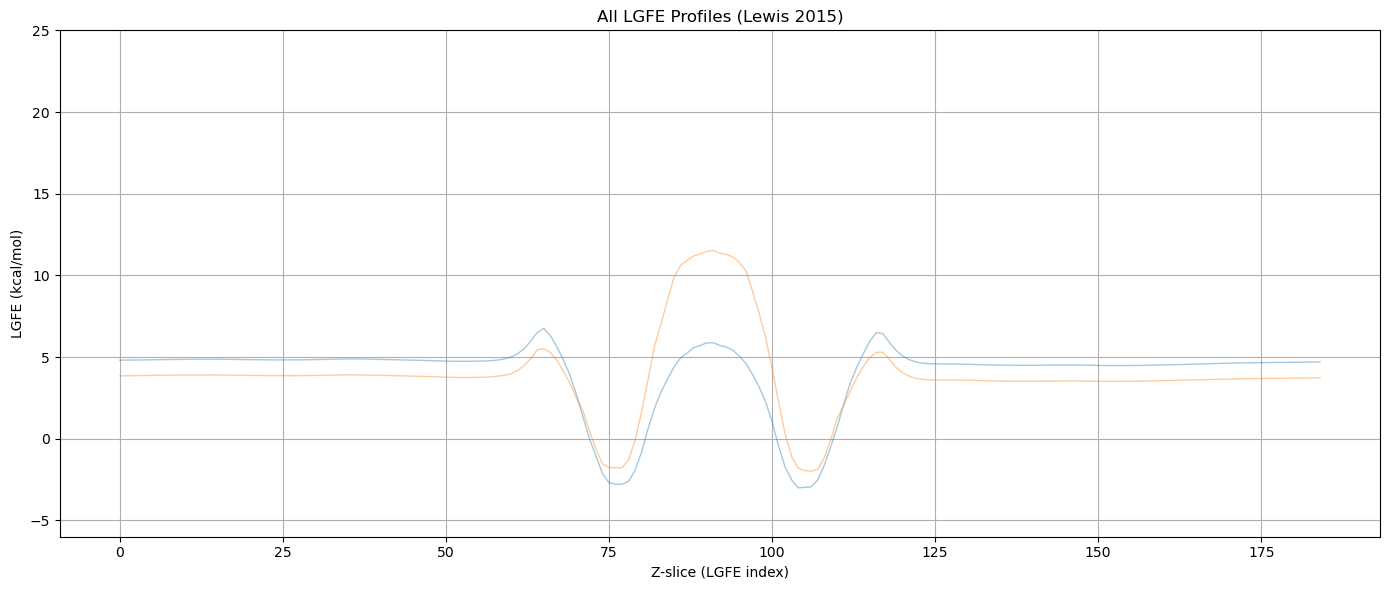

No outliers detected.


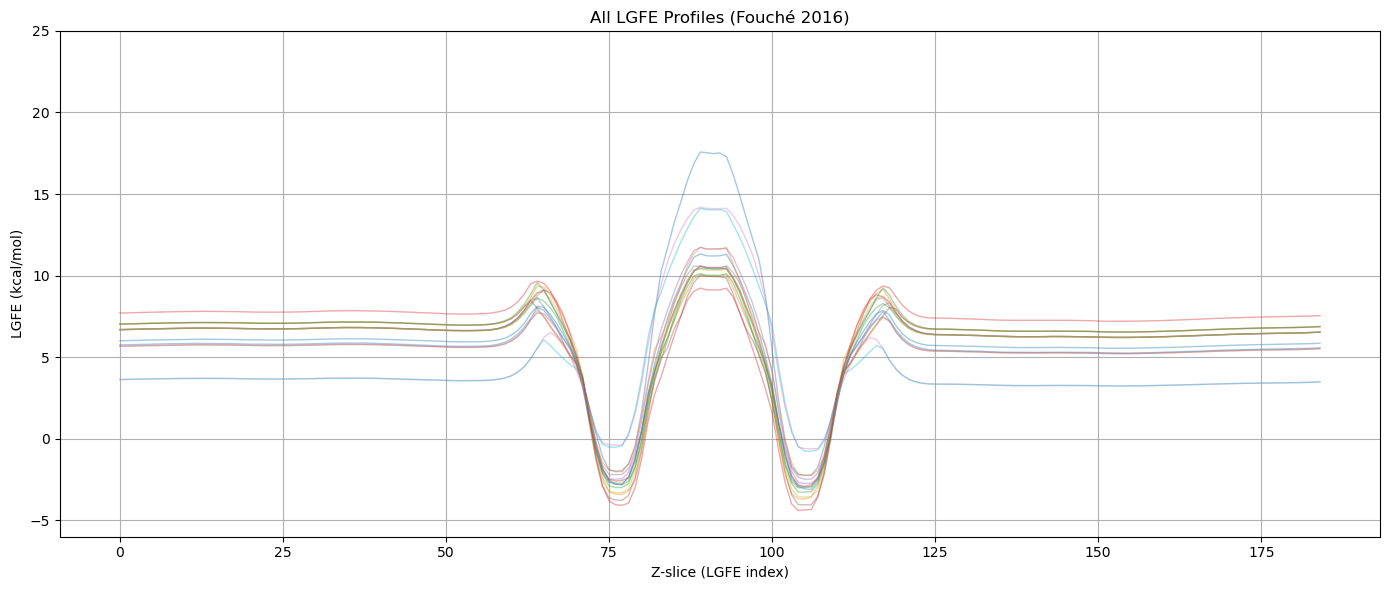

No outliers detected.


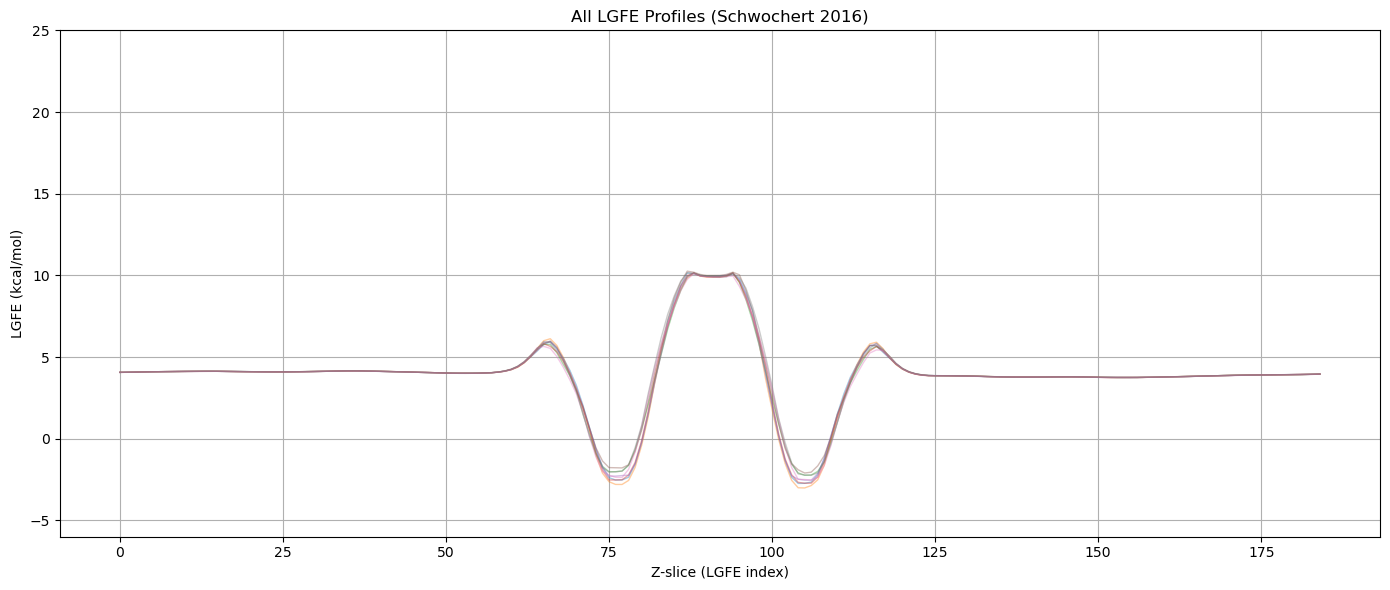

No outliers detected.


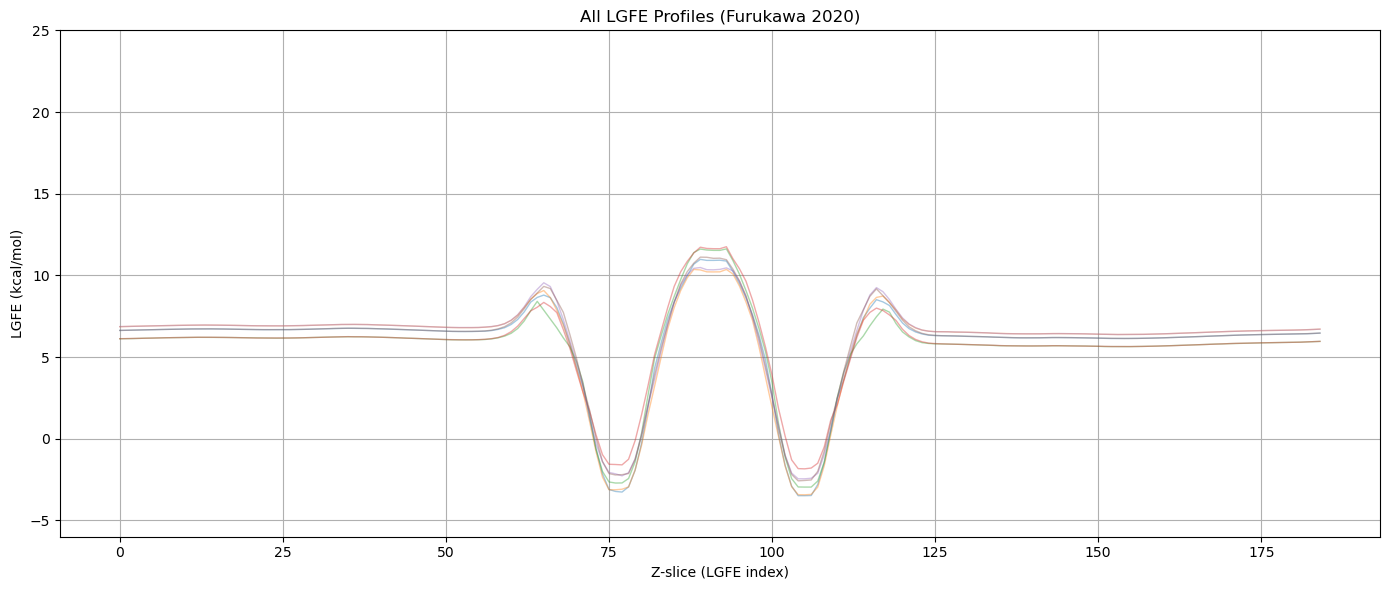

No outliers detected.


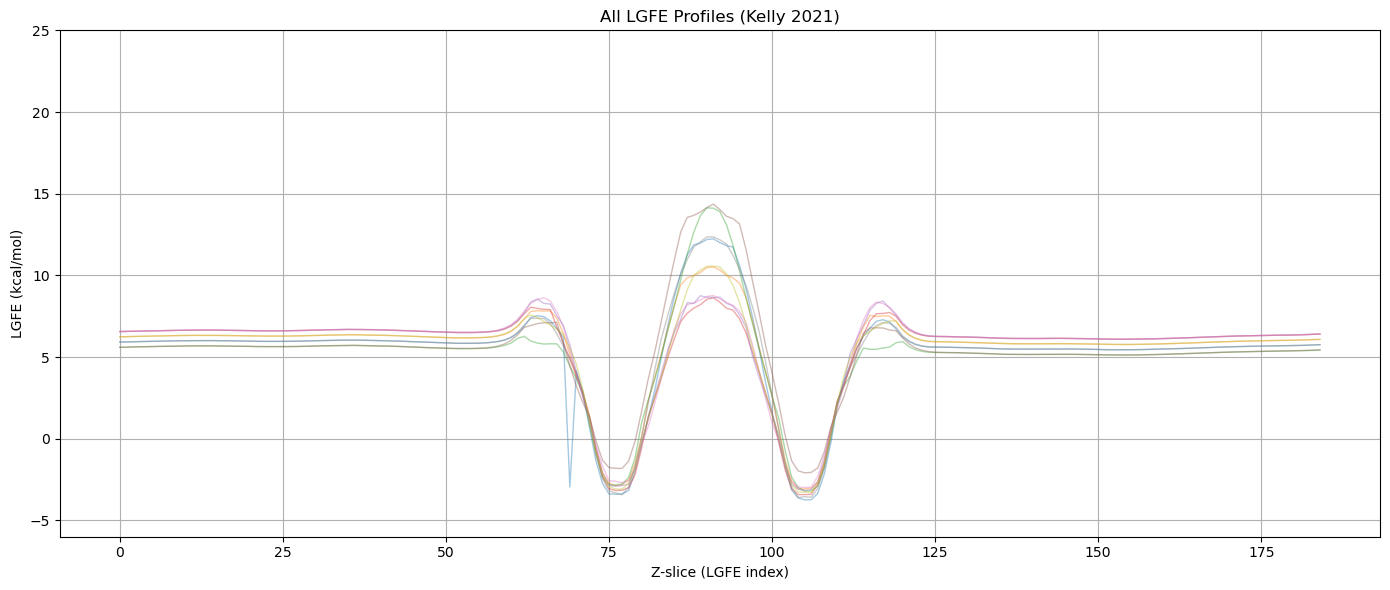

No outliers detected.


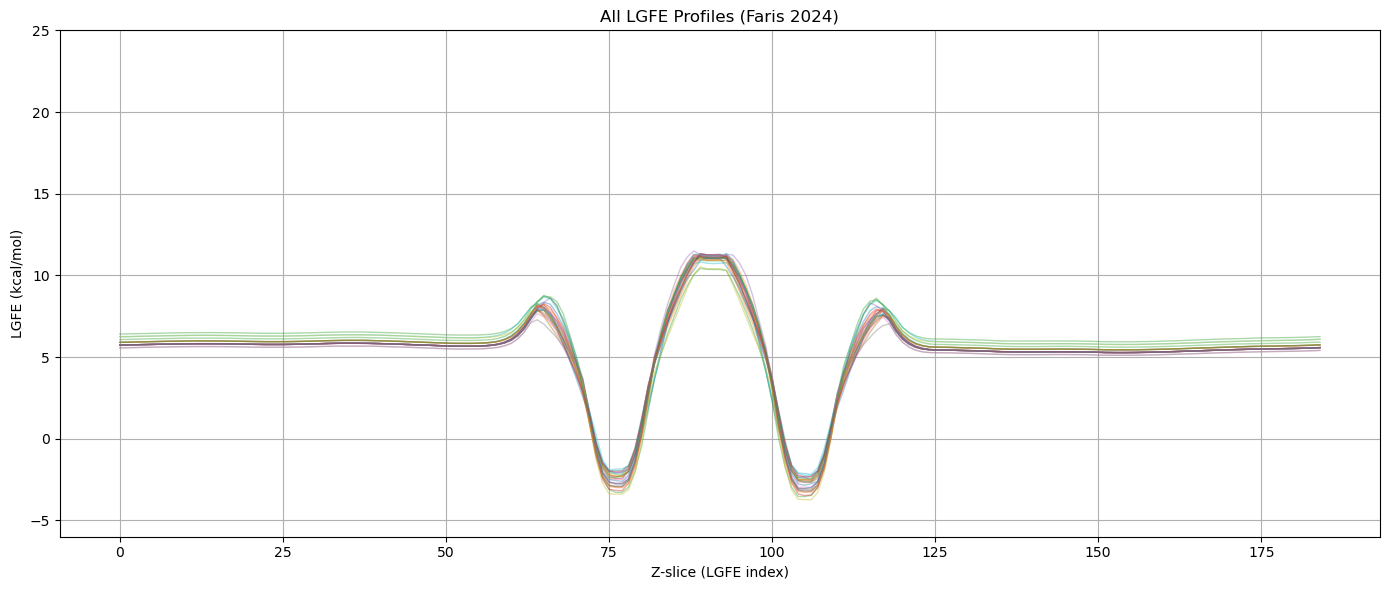

In [79]:
lgfe_cyc_1_clean, lgfe_cyc_1_sorted, df_cyc_1_clean = plot_all(df_cyc_1, memb_name="Lewis 2015")
lgfe_cyc_2_clean, lgfe_cyc_2_sorted, df_cyc_2_clean = plot_all(df_cyc_2, memb_name="Fouché 2016")
lgfe_cyc_3_clean, lgfe_cyc_3_sorted, df_cyc_3_clean = plot_all(df_cyc_3, memb_name="Schwochert 2016")
lgfe_cyc_4_clean, lgfe_cyc_4_sorted, df_cyc_4_clean = plot_all(df_cyc_4, memb_name="Furukawa 2020")
lgfe_cyc_5_clean, lgfe_cyc_5_sorted, df_cyc_5_clean = plot_all(df_cyc_5, memb_name="Kelly 2021")
lgfe_cyc_6_clean, lgfe_cyc_6_sorted, df_cyc_6_clean = plot_all(df_cyc_6, memb_name="Faris 2024")

In [80]:
df_ind_1 = pd.read_csv("../data/bbb-MDCK-MDR1-Hellinger-P_app_lgfe.csv")
df_ind_2 = pd.read_csv("../data/bbb-MDCK-Irvine-P_app_lgfe.csv")
df_ind_3 = pd.read_csv("../data/bbb-MDCK-MDR1-QWang-P_app_lgfe.csv")
df_ind_4 = pd.read_csv("../data/bbb-MDCK-MDR1-Summerfield-P_app_lgfe.csv")
df_ind_5 = pd.read_csv("../data/bbb-cMdr1_KO_MDCK1-beran-P_app_lgfe.csv")

No outliers detected.


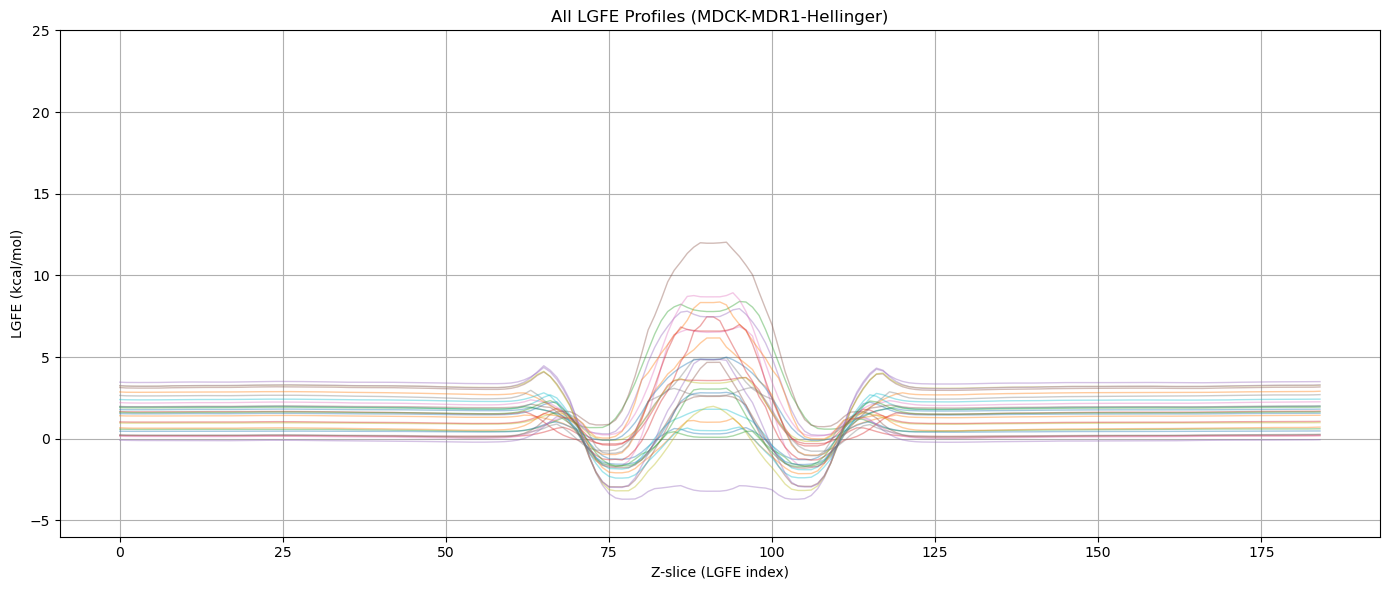

No outliers detected.


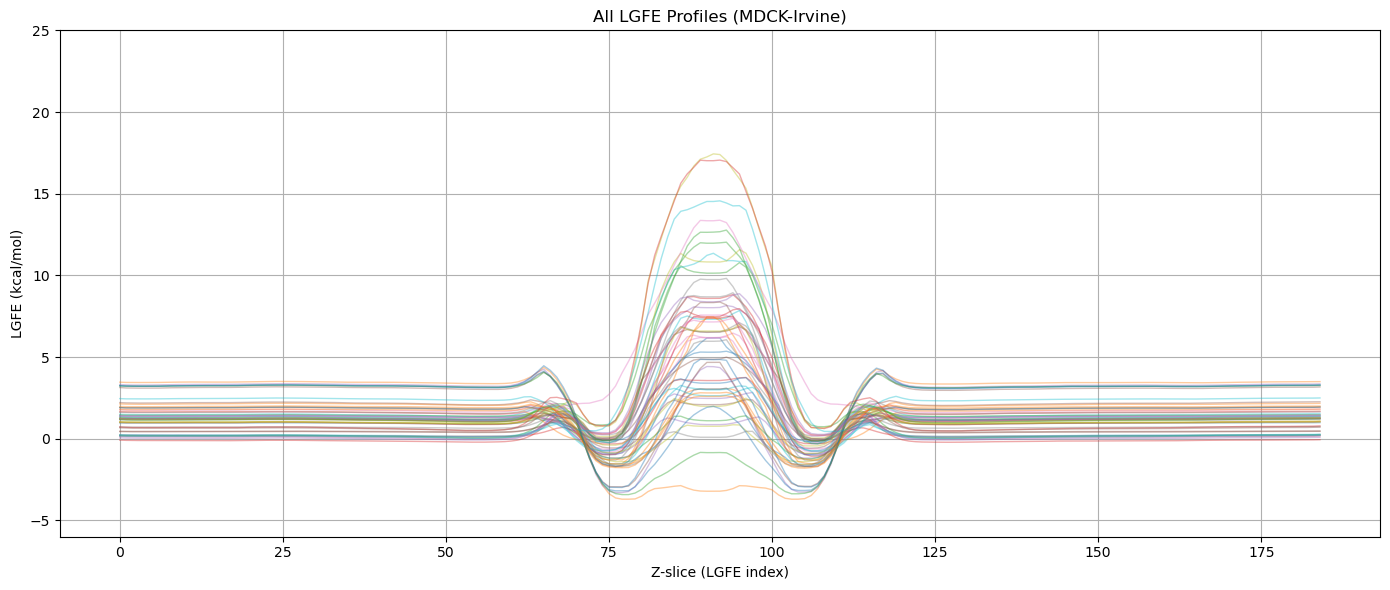

No outliers detected.


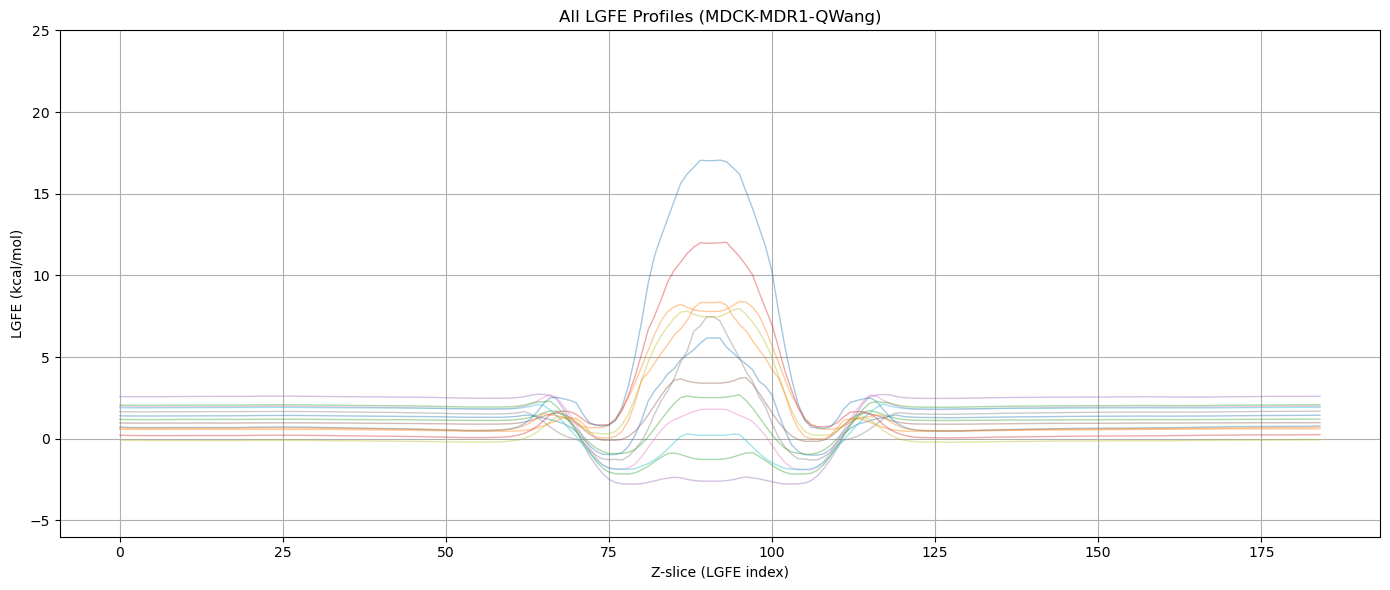

No outliers detected.


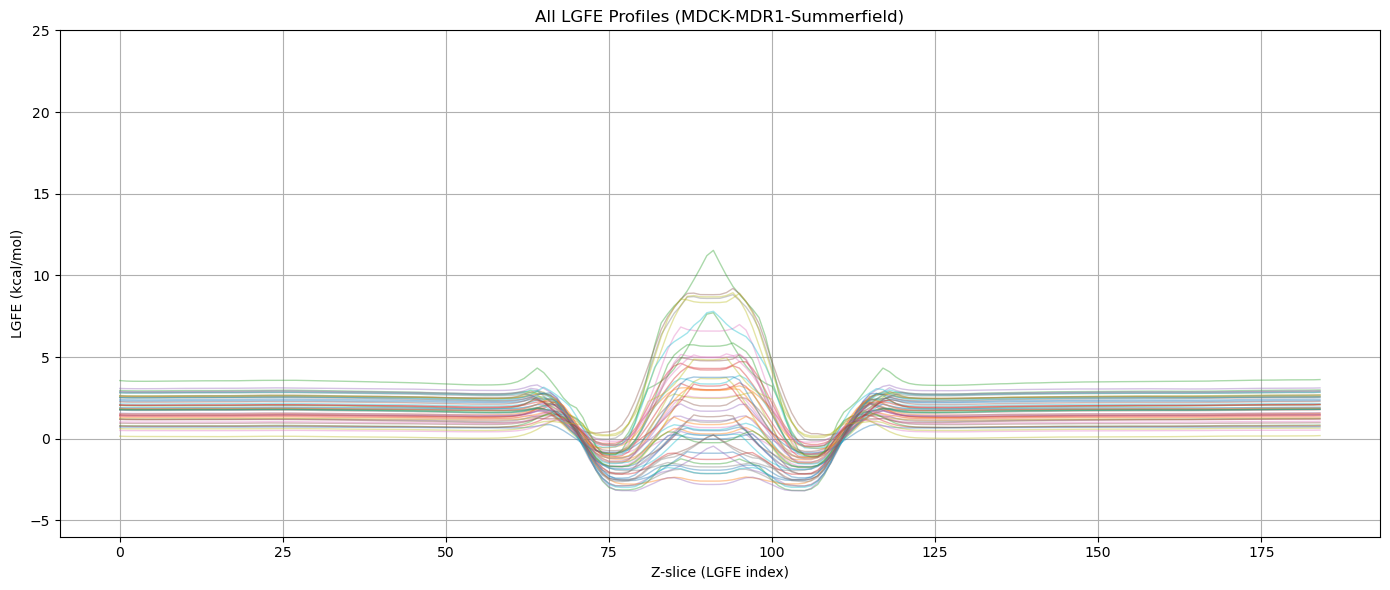

No outliers detected.


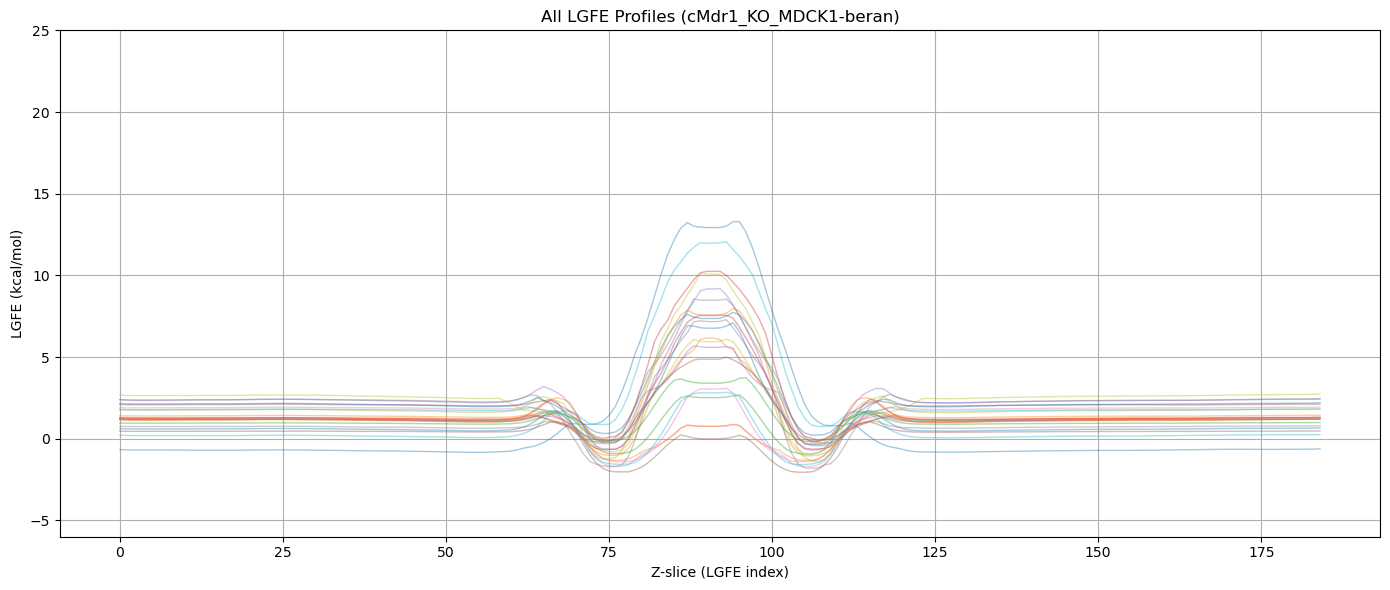

In [81]:
lgfe_ind_1_clean, lgfe_ind_1_sorted, df_ind_1_clean = plot_all(df_ind_1, memb_name="MDCK-MDR1-Hellinger")
lgfe_ind_2_clean, lgfe_ind_2_sorted, df_ind_2_clean = plot_all(df_ind_2, memb_name="MDCK-Irvine")
lgfe_ind_3_clean, lgfe_ind_3_sorted, df_ind_3_clean = plot_all(df_ind_3, memb_name="MDCK-MDR1-QWang")
lgfe_ind_4_clean, lgfe_ind_4_sorted, df_ind_4_clean = plot_all(df_ind_4, memb_name="MDCK-MDR1-Summerfield")
lgfe_ind_5_clean, lgfe_ind_5_sorted, df_ind_5_clean = plot_all(df_ind_5, memb_name="cMdr1_KO_MDCK1-beran")

In [82]:
df_cyc_1 = pd.read_csv("../data/bbb-cyclic-peptide-Source_2015_Lewis.csv")
df_cyc_2 = pd.read_csv("../data/bbb-cyclic-peptide-Source_2016_Fouché.csv")
df_cyc_3 = pd.read_csv("../data/bbb-cyclic-peptide-Source_2016_Schwochert.csv")
df_cyc_4 = pd.read_csv("../data/bbb-cyclic-peptide-Source_2020_Furukawa.csv")
df_cyc_5 = pd.read_csv("../data/bbb-cyclic-peptide-Source_2021_Kelly.csv")
df_cyc_6 = pd.read_csv("../data/bbb-cyclic-peptide-Source_2024_Faris.csv")

No outliers detected.


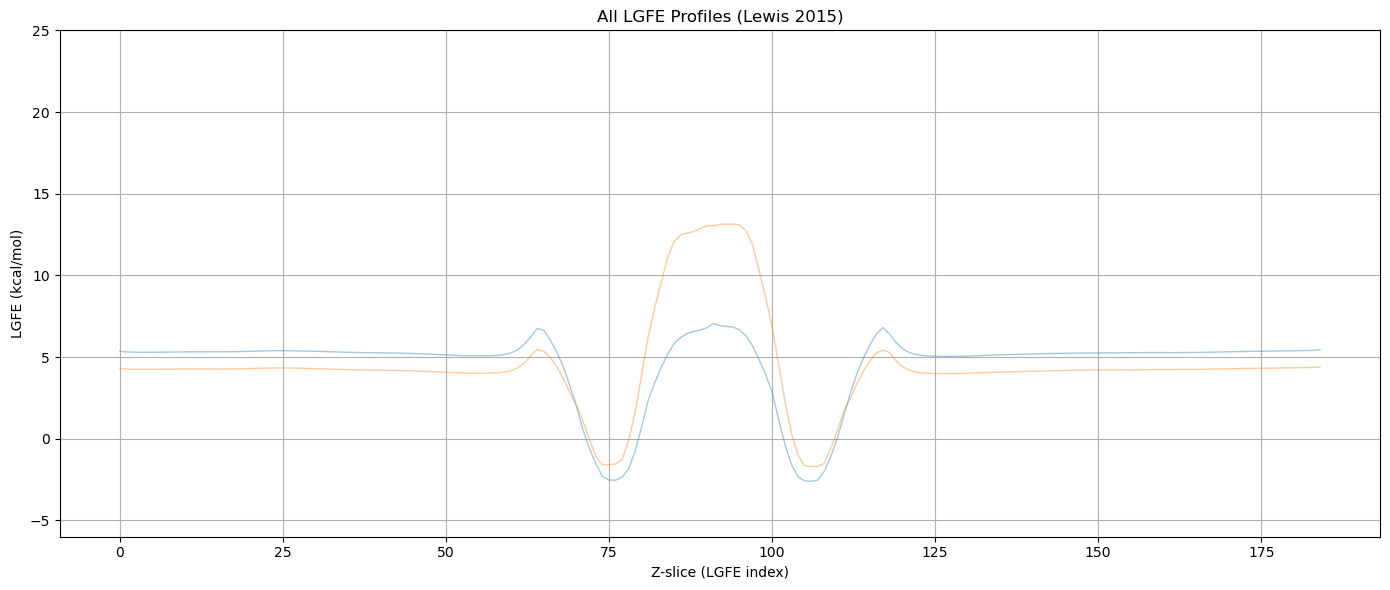

No outliers detected.


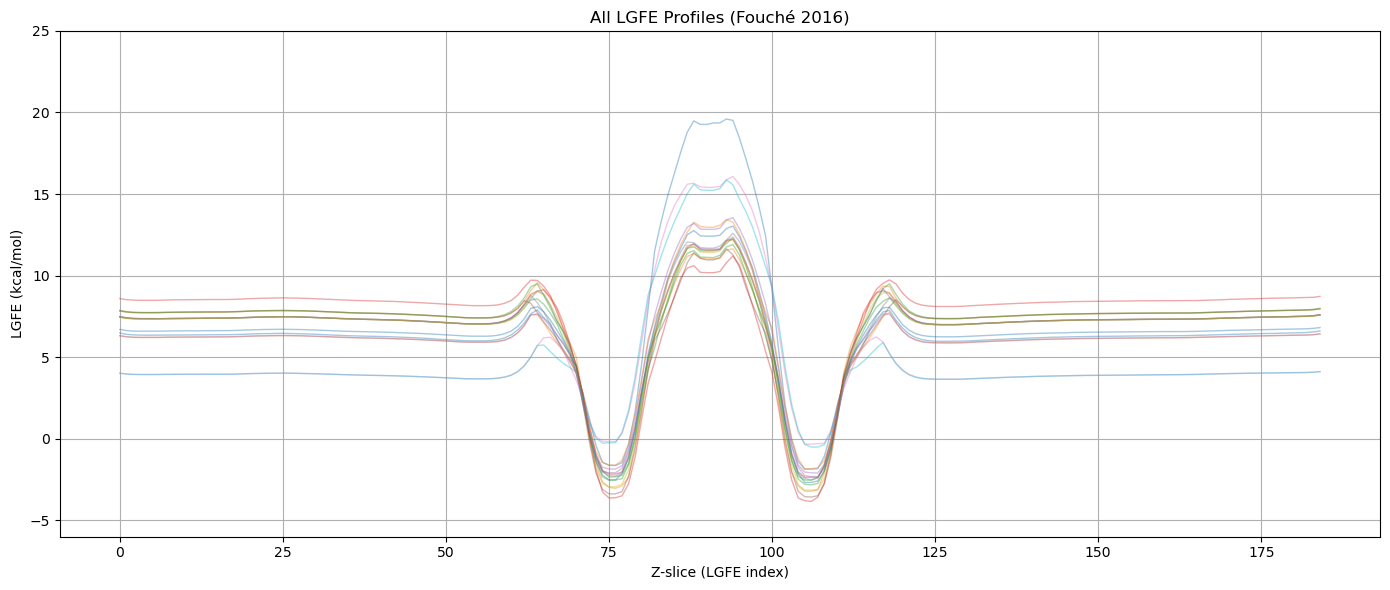

No outliers detected.


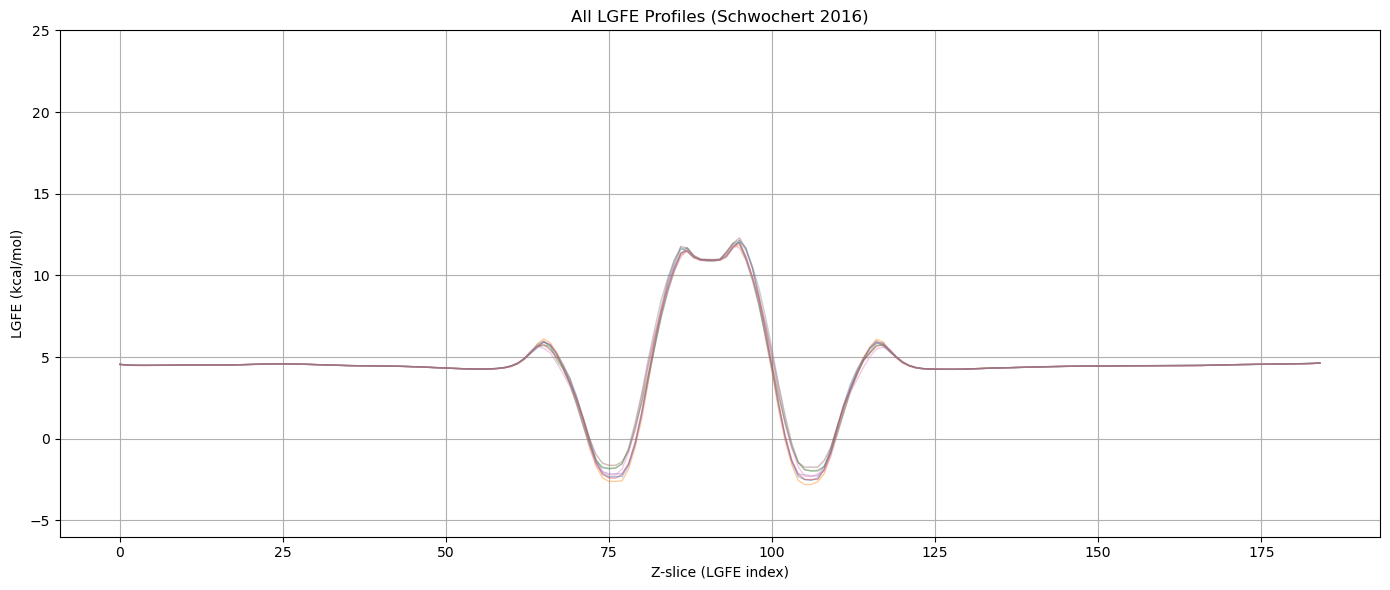

No outliers detected.


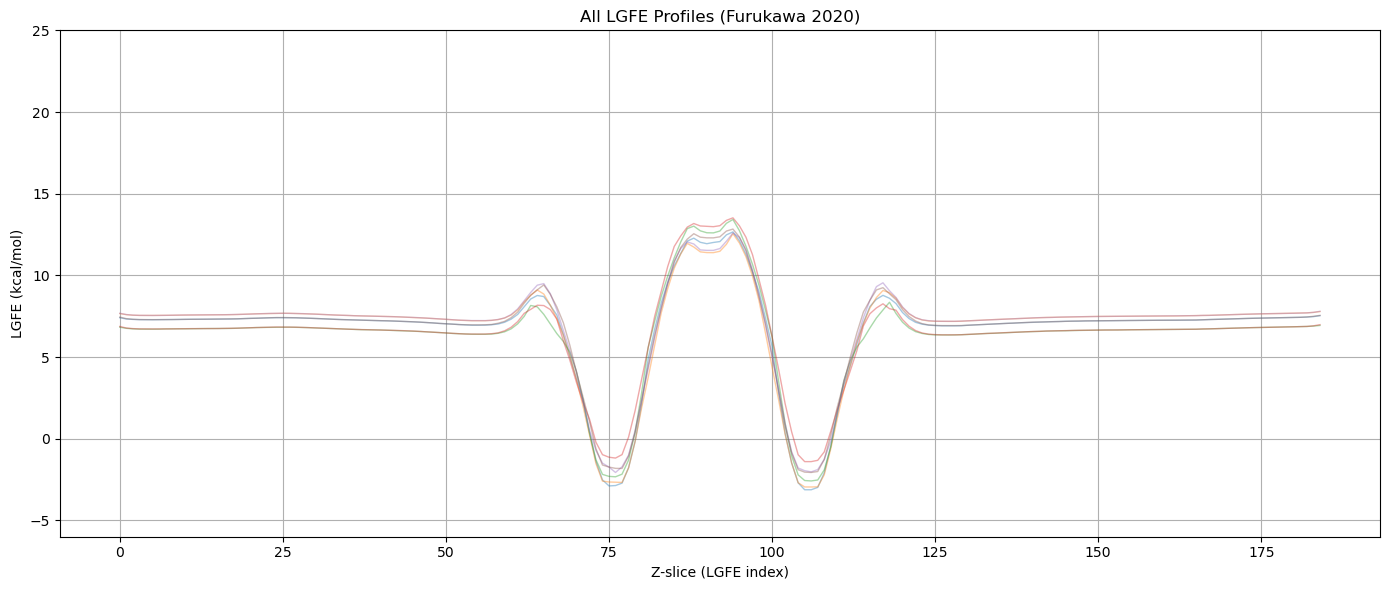

No outliers detected.


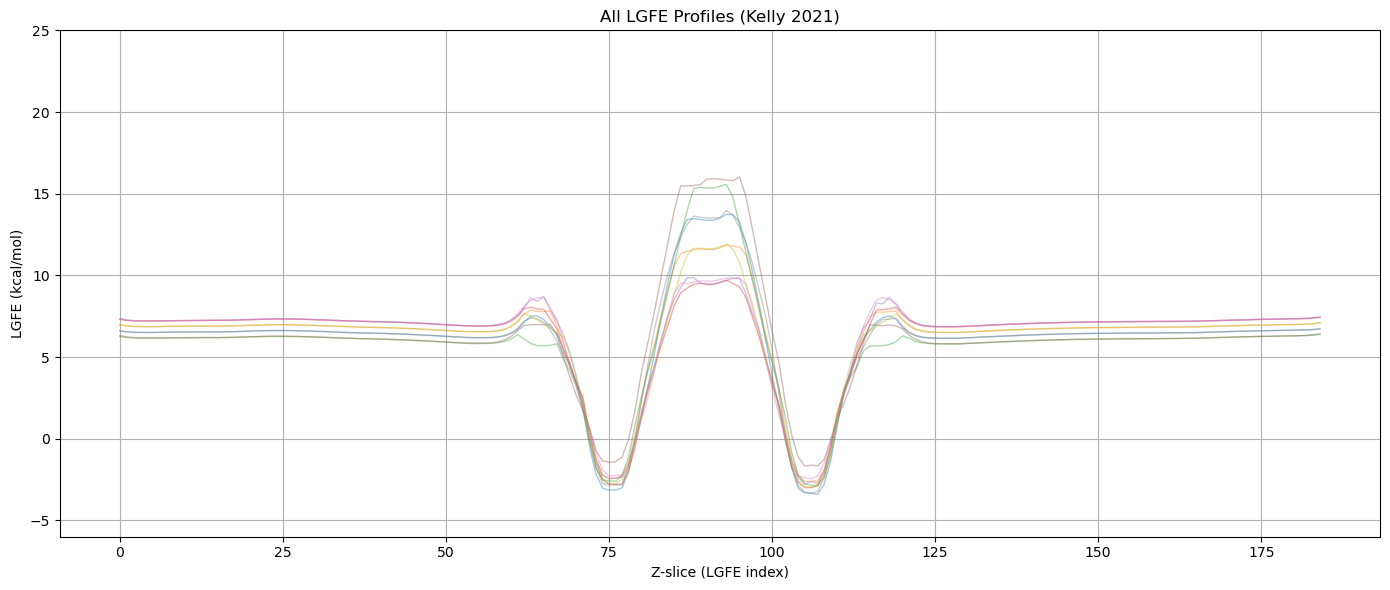

No outliers detected.


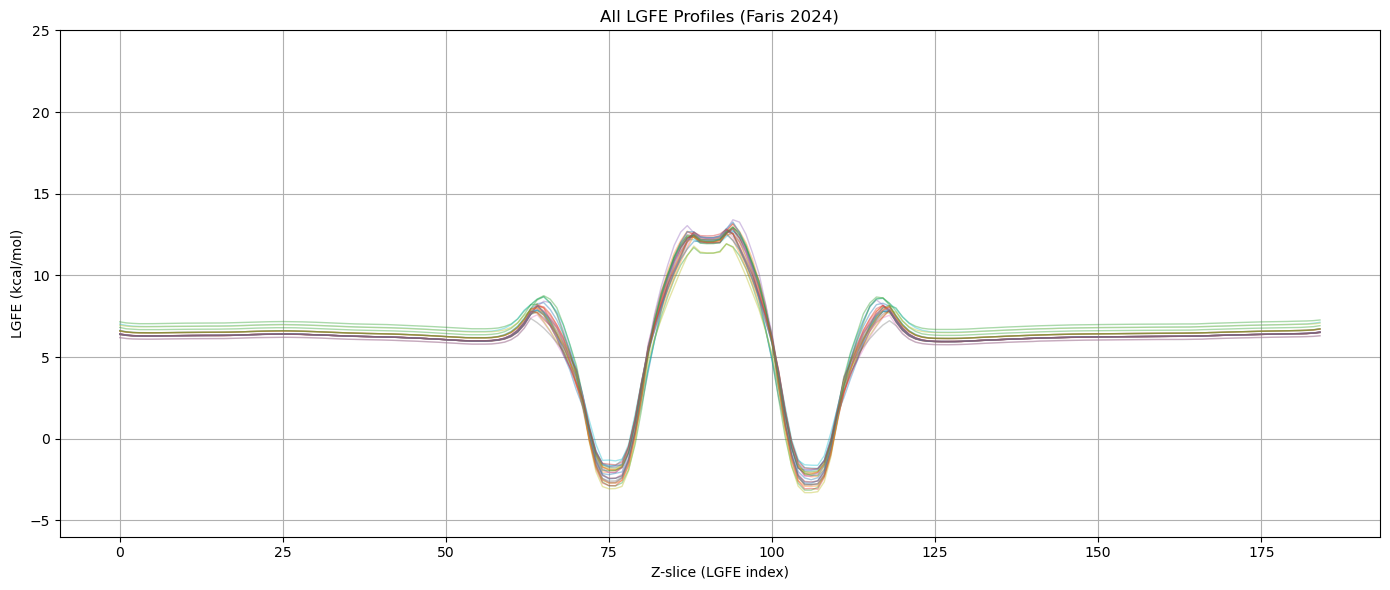

In [83]:
lgfe_cyc_1_clean, lgfe_cyc_1_sorted, df_cyc_1_clean = plot_all(df_cyc_1, memb_name="Lewis 2015")
lgfe_cyc_2_clean, lgfe_cyc_2_sorted, df_cyc_2_clean = plot_all(df_cyc_2, memb_name="Fouché 2016")
lgfe_cyc_3_clean, lgfe_cyc_3_sorted, df_cyc_3_clean = plot_all(df_cyc_3, memb_name="Schwochert 2016")
lgfe_cyc_4_clean, lgfe_cyc_4_sorted, df_cyc_4_clean = plot_all(df_cyc_4, memb_name="Furukawa 2020")
lgfe_cyc_5_clean, lgfe_cyc_5_sorted, df_cyc_5_clean = plot_all(df_cyc_5, memb_name="Kelly 2021")
lgfe_cyc_6_clean, lgfe_cyc_6_sorted, df_cyc_6_clean = plot_all(df_cyc_6, memb_name="Faris 2024")